# Teste de granularidade para modelos de ML

## Bibliotecas

In [2]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

from keras.models import Model
from keras.layers import Input, Dense, GRU as GRU_layer, LSTM as LSTM_layer, SimpleRNN as RNN_layer
from keras.layers import Flatten,  Dropout
from tensorflow import cast, float32,reduce_mean,maximum
import tensorflow as tf
from keras.backend import epsilon
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle
import optuna
import pmdarima as pm
import itertools
import joblib


2026-05-05 11:05:58.713808: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 11:05:58.726895: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 11:05:59.322174: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 11:06:00.727469: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

## carregando os dados

In [24]:


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_day'
#tempo_dia = pd.read_csv('../../data/times/times_1_day.csv')
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
# 2. Use glob to get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_dia = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_dia.append(df)

    #print(f"Loaded '{file}' as dataframe '{filename}'")

# --- Now you can access any dataframe by its filename ---
df_day = pd.concat(lista_dia, ignore_index=True)
del lista_dia
print("\n--- All dataframes loaded successfully! ---")


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_hour'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_hora = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_hora.append(df)
df_hour = pd.concat(lista_hora, ignore_index=True)
del lista_hora
# --- Now you can access any dataframe by its filename ---
print("\n--- All dataframes loaded successfully! ---")



# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_10_minutes'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_min = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = os.path.splitext(os.path.basename(file))[0]
    
    
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_min.append(df)

# --- Now you can access any dataframe by its filename ---
df_10min = pd.concat(lista_min, ignore_index=True)
del lista_min
print("\n--- All dataframes loaded successfully! ---")

1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---


## Analise exploratória para redução de dados
Ao fazer a analise, entende-se que os dados possuem variancias bem distintas e escolhe-se alguns exemplares para fazer os experimentos


Instituições com poucos dados: 5
Instituições com pelo menos 1 nulo: 0
Instituições com variância zero: 0
Instituições com valores negativos: 0
Instituições com outliers: 176
Instituições restantes: 102


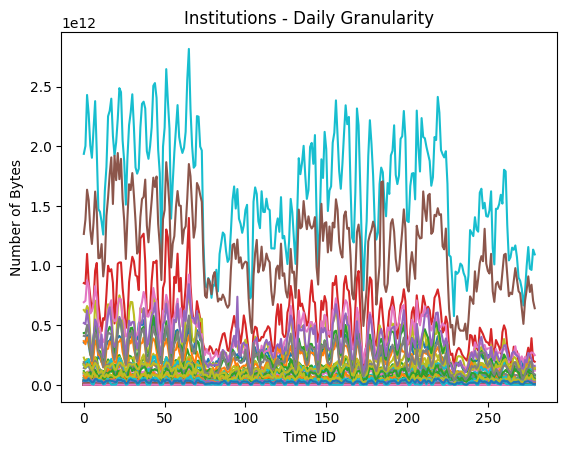

In [25]:
import matplotlib.pyplot as plt
import numpy as np
#analise dos dados diários
inst = []
p_d = 0
val_null = 0
var_z = 0
val_neg = 0
out = 0
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True
    Q1 = instituicao["n_bytes"].quantile(0.20)
    Q3 = instituicao["n_bytes"].quantile(0.80)
    IQR = Q3 - Q1
    L_inferior = Q1 - 1.5*IQR
    L_superior = Q3 + 1.5*IQR

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 260:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        p_d += 1

    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_null += 1

    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        var_z += 1

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_neg += 1

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[(instituicao["n_bytes"] > L_superior) | (instituicao["n_bytes"] < L_inferior)].shape[0]>0:
        serve = False
        out += 1


    if serve:
        inst.append(i)

print(f"Instituições com poucos dados: {p_d}")
print(f"Instituições com pelo menos 1 nulo: {val_null}")
print(f"Instituições com variância zero: {var_z}")
print(f"Instituições com valores negativos: {val_neg}")
print(f"Instituições com outliers: {out}")
print(f"Instituições restantes: {len(inst)}")
inst.remove('243')
for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.show()

df_day = df_day[df_day["id_institution"].isin(inst)]
df_hour = df_hour[df_hour["id_institution"].isin(inst)]
df_10min = df_10min[df_10min["id_institution"].isin(inst)]





  
print()

## Funções tratamento e separação de dados

In [4]:
def complete_id(df):
    df = df.copy()
    
    # 1. Cria um MultiIndex com TODAS as combinações teóricas possíveis 
    # (24 horas * 60 minutos = 1440 linhas por ID)
    ids_unicos = df['ID'].unique()
    horas = range(24)
    minutos = range(6)
    
    # Gera a malha cartesiana (ID x Hora x Minuto)
    multi_idx = pd.MultiIndex.from_product(
        [ids_unicos, horas, minutos], 
        names=['ID', 'hour_id', 'min_id']
    )
    
    # 2. Configura a base atual para usar essas três colunas como índice e remove duplicatas
    # O drop_duplicates evita o erro fatal se a sua base original tiver duas marcações exatas no mesmo minuto
    df = df.drop_duplicates(subset=['ID', 'hour_id', 'min_id'])
    df = df.set_index(['ID', 'hour_id', 'min_id'])
    
    # 3. O REINDEX MÁGICO: Ele vai criar as linhas em branco para as horas/minutos que não existem
    df_full = df.reindex(multi_idx).reset_index()
    
    # 4. Preenchimento (Fill)
    # Primeiro agrupa pelo ID para garantir que o bfill/ffill de uma instituição/dia não vaze para outra
    def preencher_gaps(g):
        # Garante a ordem cronológica
        g = g.sort_values(['hour_id', 'min_id'])
        
        # Preenche a id_institution 
        if 'id_institution' in g.columns:
            g['id_institution'] = g['id_institution'].ffill().bfill()
            
        # Preenche as colunas de bytes (ajuste os nomes conforme sua base)
        if 'n_bytes_hour' in g.columns:
            g['n_bytes_hour'] = g['n_bytes_hour'].ffill().bfill()
        if 'n_bytes_10minutes' in g.columns:
            g['n_bytes_10minutes'] = g['n_bytes_10minutes'].ffill().bfill()
            
        # Preenche o resto (exceto as chaves de índice)
        for col in g.columns:
            if col not in ['ID', 'hour_id', 'min_id', 'id_institution', 'n_bytes_hour', 'n_bytes_10minutes']:
                g[col] = g[col].ffill().bfill()
                
        return g

    # Aplica o preenchimento por grupo (por ID)
    df_out = df_full.groupby('ID', group_keys=False).apply(preencher_gaps)
    
    return df_out.reset_index(drop=True)

def treino_val_teste(df = pd.Series, t_treino = 0, t_teste = 0, t_val = 0):
    return  df[:int(t_treino*len(df))], df[int(t_treino*len(df)):int((t_treino + t_val)*len(df))]  , df[int((t_treino + t_val)*len(df)):]

def scaling(df_series: pd.Series, mode = 0, scaler = None) -> pd.Series:
    if mode == 0:
        scaler = MinMaxScaler()
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.fit_transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name),scaler
    elif mode == 1:
        dados_reshaped = df_series.values.reshape(-1, 1)
        dados_scaled = scaler.transform(dados_reshaped)
        return pd.Series(dados_scaled.flatten(), index=df_series.index, name=df_series.name)     

def sliding_window (df_series: pd.Series, inputs: int, outputs: int, step: int = 1) -> pd.DataFrame:

    total_window_size = inputs + outputs
    
    # 1. Validação
    if len(df_series) < total_window_size:
        print(f"Erro: Tamanho dos dados ({len(df_series)}) é menor que a janela total ({total_window_size})")
        return pd.DataFrame() # Retorna um DataFrame vazio

    # 2. Cria as janelas (sliding windows)
    windowed_data = []
    # Itera do primeiro índice inicial possível até o último
    for i in range(0, len(df_series) - total_window_size + 1, step):
        # A fatia vai de 'i' até 'i + tamanho_total'
        window_slice = df_series.iloc[i : i + total_window_size].values
        windowed_data.append(window_slice)

    # 3. Define os nomes das colunas
    x_cols = [f"x_{j}" for j in range(inputs)]
    y_cols = [f"y_{o}" for o in range(outputs)]
    
    # 4. Cria o DataFrame final
    df_windowed = pd.DataFrame(windowed_data, columns=x_cols + y_cols)
    return df_windowed


## Tratamento de dados faltantes

In [5]:
time_day = pd.read_csv('../../data/times/times_1_day.csv')
time_hour = pd.read_csv('../../data/times/times_1_hour.csv')
time_minute = pd.read_csv('../../data/times/times_10_minutes.csv')

df_day["id_time"] = df_day["id_time"].astype(int)
df_hour["id_time"] = df_hour["id_time"].astype(int)
df_10min["id_time"] = df_10min["id_time"].astype(int)

df_day = df_day.merge(time_day, on="id_time", how="left")
df_day["time"] = pd.to_datetime(df_day["time"])
df_day["time_day"] = df_day["time"].dt.date
df_day["ID"] = df_day["id_institution"].astype(str) + "_" + df_day["time_day"].astype(str)
df_day.drop(columns=["id_time", "time"], inplace=True)

df_hour = df_hour.merge(time_hour, on="id_time", how="left")
df_hour["time"] = pd.to_datetime(df_hour["time"])
df_hour["time_day"] = df_hour["time"]
df_hour["time_day"] = df_hour["time_day"].dt.date
df_hour["ID"] = df_hour["id_institution"].astype(str) + "_" + df_hour["time_day"].astype(str)
df_hour["hour_id"] = pd.to_datetime(df_hour["time"]).dt.hour
df_hour.drop(columns=["id_time", "time", "id_institution"], inplace=True)

df_10min = df_10min.merge(time_minute, on="id_time", how="left")
df_10min["time"] = pd.to_datetime(df_10min["time"], utc = True)
df_10min["ID"] = df_10min["id_institution"].astype(str) + "_" + (df_10min["time"].dt.date).astype(str)
df_10min["min_id"] = df_10min["time"].dt.minute
df_10min["min_id"] = df_10min["min_id"].astype(int)
df_10min["min_id"] = df_10min["min_id"] // 10
df_10min["sec_id"] = df_10min["time"].dt.second
df_10min.drop(columns=["id_time", "time", "id_institution"], inplace=True)

df_merged = df_day.merge(df_hour, on="ID", how="left", suffixes=("_day", "_hour"))
df_merged = df_merged.merge(df_10min, on = "ID", how = "left", suffixes = ("_day", "_10min"))
df_merged.drop(columns=["time_day_hour", "time_day_day"], inplace=True)
df_merged.rename(columns={"n_bytes": "n_bytes_10minutes"}, inplace = True)

df_completo = complete_id(df_merged)

df_day = df_completo[["ID", "id_institution", "n_bytes_day"]].drop_duplicates().copy()
df_day.rename(columns={"n_bytes_day": "n_bytes"}, inplace=True)
df_hour = df_completo[["ID", "id_institution", "hour_id", "n_bytes_hour"]].drop_duplicates().copy()
df_hour.rename(columns={"n_bytes_hour": "n_bytes"}, inplace=True)
df_hour["ID"] = df_hour["ID"] + "_" + df_hour["hour_id"].astype(str)
df_hour.drop(columns=["hour_id"], inplace=True)
df_10min = df_completo[["id_institution", "hour_id","min_id", "n_bytes_10minutes"]].drop_duplicates().copy()
df_10min.rename(columns={"n_bytes_10minutes": "n_bytes"}, inplace=True)


/tmp/ipykernel_603722/2901186231.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_out = df_full.groupby('ID', group_keys=False).apply(preencher_gaps)


## Tratando [DIA] e separando em treino, val e teste

In [6]:


inputs_day = 7
outputs_day = 1
x_cols = [f"x_{j}" for j in range(inputs_day)]
y_cols = [f"y_{o}" for o in range(outputs_day)]
train_list = []
val_list = []
test_list = []
train_list_1d = []
test_list_1d = [] 
val_list_1d = []
for i in inst:
    print(i)
    serie = pd.Series(df_day[df_day["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_day + outputs_day):
        _train_day, _val_day, _test_day  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_day,scaler = scaling(_train_day,0)
        test_day = scaling(_test_day,1,scaler)
        val_day = scaling(_val_day,1,scaler)

        train_day_ = sliding_window(df_series = train_day, inputs = inputs_day, outputs = outputs_day)
        train_day_.insert(0, "id_institution", i)
        train_list.append(train_day_)

        test_day_ = sliding_window(df_series = test_day, inputs = inputs_day, outputs = outputs_day)
        test_day_.insert(0, "id_institution", i)
        test_list.append(test_day_)

        val_day_ = sliding_window(df_series = val_day, inputs = inputs_day, outputs = outputs_day)
        val_day_.insert(0, "id_institution", i)
        val_list.append(val_day_)

    else: print(f"   dataset pequeno ({tamanho})")
train_day_wind = pd.concat(train_list, ignore_index=True)
val_day_wind = pd.concat(val_list, ignore_index=True)
test_day_wind = pd.concat(test_list, ignore_index=True)
inst_day = list(train_day_wind["id_institution"].unique())
print("\n\n" + str(len(inst_day)))
del train_list, val_list, test_list
train_day_wind.to_csv('../../data/Tabelas_criadas/treino_dia.csv', index = False)
test_day_wind.to_csv('../../data/Tabelas_criadas/teste_dia.csv', index = False)
val_day_wind.to_csv('../../data/Tabelas_criadas/val_dia.csv', index = False)


68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


101


In [7]:
# O '.joblib' ou '.pkl' são extensões padrão para esse tipo de arquivo
caminho_arquivo = '../scalers/scalers_day.joblib'

inputs_day = 7
outputs_day = 1
x_cols = [f"x_{j}" for j in range(inputs_day)]
y_cols = [f"y_{o}" for o in range(outputs_day)]
scalers_day = {}
for i in inst:
    serie = pd.Series(df_day[df_day["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_day + outputs_day):
        _train_day, _val_day, _test_day  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_day,scaler = scaling(_train_day,0)
        test_day = scaling(_test_day,1,scaler)
        val_day = scaling(_val_day,1,scaler)
        scalers_day[i] = scaler

# Salva o seu dicionário inteiro de uma só vez
joblib.dump(scalers_day, caminho_arquivo)

['../scalers/scalers_day.joblib']

## Tratando [HORAS] e separando em treino, val e teste

In [8]:


inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        train_hour_ = sliding_window(df_series = train_hour, inputs = inputs_hour, outputs = outputs_hour)
        train_hour_.insert(0, "id_institution", i)
        train_list.append(train_hour_)

        test_hour_ = sliding_window(df_series = test_hour, inputs = inputs_hour, outputs = outputs_hour)
        test_hour_.insert(0, "id_institution", i)
        test_list.append(test_hour_)

        val_hour_ = sliding_window(df_series = val_hour, inputs = inputs_hour, outputs = outputs_hour)
        val_hour_.insert(0, "id_institution", i)
        val_list.append(val_hour_)
    else: print(f"   dataset pequeno ({tamanho})")

train_hour_wind = pd.concat(train_list, ignore_index=True)
val_hour_wind = pd.concat(val_list, ignore_index=True)
test_hour_wind = pd.concat(test_list, ignore_index=True)


train_hour_wind.to_csv('../../data/Tabelas_criadas/treino_hora.csv', index = False)
test_hour_wind.to_csv('../../data/Tabelas_criadas/teste_hora.csv', index = False)
val_hour_wind.to_csv('../../data/Tabelas_criadas/val_hora.csv', index = False)

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


In [10]:


inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        train_hour_ = sliding_window(df_series = train_hour, inputs = inputs_hour, outputs = outputs_hour, step=24)
        train_hour_.insert(0, "id_institution", i)
        train_list.append(train_hour_)

        test_hour_ = sliding_window(df_series = test_hour, inputs = inputs_hour, outputs = outputs_hour, step=24)
        test_hour_.insert(0, "id_institution", i)
        test_list.append(test_hour_)

        val_hour_ = sliding_window(df_series = val_hour, inputs = inputs_hour, outputs = outputs_hour, step=24)
        val_hour_.insert(0, "id_institution", i)
        val_list.append(val_hour_)
    else: print(f"   dataset pequeno ({tamanho})")

train_hour_wind = pd.concat(train_list, ignore_index=True)
val_hour_wind = pd.concat(val_list, ignore_index=True)
test_hour_wind = pd.concat(test_list, ignore_index=True)


train_hour_wind.to_csv('../../data/Tabelas_criadas/treino_hora_steped.csv', index = False)
test_hour_wind.to_csv('../../data/Tabelas_criadas/teste_hora_steped.csv', index = False)
val_hour_wind.to_csv('../../data/Tabelas_criadas/val_hora_steped.csv', index = False)

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


In [9]:

caminho_arquivo = '../scalers/scalers_hour.joblib'
inputs_hour = 7*24
outputs_hour = 1*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]
train_list_1d = []
test_list_1d = [] 
val_list_1d = []
scalers_hour = {}
for i in inst:
    serie = pd.Series(df_hour[df_hour["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_hour,scaler = scaling(_train_hour,0)
        test_hour = scaling(_test_hour,1,scaler)
        val_hour = scaling(_val_hour,1,scaler)
        scalers_hour[i] = scaler

joblib.dump(scalers_hour, caminho_arquivo)

['../scalers/scalers_hour.joblib']

## Tratando [MINUTOS] e separando em treino, val e teste
por enquano, este vai ficar de escanteio por precisar de um tratamento mais especifico


In [10]:


inputs_10min = 7*24*6
outputs_10min = 1*24*6
x_cols = [f"x_{j}" for j in range(inputs_10min)]
y_cols = [f"y_{o}" for o in range(outputs_10min)]
train_list = []
val_list = []
test_list = []
for i in inst:
    print(i)
    serie = pd.Series(df_10min[df_10min["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_10min + outputs_10min):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_10min,scaler = scaling(_train_hour,0)
        test_10min = scaling(_test_hour,1,scaler)
        val_10min = scaling(_val_hour,1,scaler)
        train_10min_ = sliding_window(df_series = train_10min, inputs = inputs_10min, outputs = outputs_10min, step = 5)
        train_10min_["id_institution"] = i
        train_list.append(train_10min_)

        test_10min_ = sliding_window(df_series = test_10min, inputs = inputs_10min, outputs = outputs_10min, step = 1)
        test_10min_["id_institution"] = i
        test_list.append(test_10min_)
        val_10min_ = sliding_window(df_series = val_10min, inputs = inputs_10min, outputs = outputs_10min, step = 5)
        val_10min_["id_institution"] = i
        val_list.append(val_10min_)
    else: print(f"   dataset pequeno ({tamanho})")

train_10min_wind = pd.concat(train_list, ignore_index=True)
val_10min_wind = pd.concat(val_list, ignore_index=True)
test_10min_wind = pd.concat(test_list, ignore_index=True)
inst_10min = list(train_10min_wind["id_institution"].unique())
print("\n\n" + str(len(inst_10min)))


train_10min_wind.to_csv('../../data/Tabelas_criadas/treino_10min.csv', index = False)
test_10min_wind.to_csv('../../data/Tabelas_criadas/teste_10min.csv', index = False)
val_10min_wind.to_csv('../../data/Tabelas_criadas/val_10min.csv', index = False)

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


101


In [12]:

caminho_arquivo = '../scalers/scalers_10min.joblib'

inputs_10min = 2*24*6
outputs_10min = 1*24*6
x_cols = [f"x_{j}" for j in range(inputs_10min)]
y_cols = [f"y_{o}" for o in range(outputs_10min)]
train_list = []
val_list = []
test_list = []
scalers_10min = {}
for i in inst:
    print(i)
    serie = pd.Series(df_10min[df_10min["id_institution"] == i]["n_bytes"].fillna(0)).astype(np.float32)
    tamanho = len(serie) 
    
    if tamanho > 10*(inputs_10min + outputs_10min):
        _train_hour, _val_hour, _test_hour  = treino_val_teste(serie, 0.6,0.1,1-0.6-0.1)
        train_10min,scaler = scaling(_train_hour,0)

        scalers_10min[i] = scaler

joblib.dump(scalers_10min, caminho_arquivo)

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104


['../scalers/scalers_10min.joblib']

## Dados já carregados

### Dia

In [3]:




inputs_day = 7
outputs_day = 1
train_day_wind = pd.read_csv('../../data/Tabelas_criadas/treino_dia.csv')
np_train_d = np.array(train_day_wind)
del train_day_wind
test_day_wind = pd.read_csv('../../data/Tabelas_criadas/teste_dia.csv')
np_test_d = np.array(test_day_wind)
del test_day_wind
val_day_wind = pd.read_csv('../../data/Tabelas_criadas/val_dia.csv')
np_val_d = np.array(val_day_wind)
del val_day_wind
X_train_d = np_train_d[:, :inputs_day + 1].astype('float32')
y_train_d = np_train_d[:, inputs_day+1:].astype('float32')
X_test_d = np_test_d[:, :inputs_day + 1].astype('float32')
y_test_d = np_test_d[:, np.r_[inputs_day+1:inputs_day+1+y_train_d.shape[1],0]].astype('float32')
X_val_d = np_val_d[:, :inputs_day + 1].astype('float32')
y_val_d = np_val_d[:, inputs_day+1:].astype('float32')



### Hora

In [4]:


inputs_hour = 7*24
outputs_hour = 1*24
train_hour_wind = pd.read_csv('../../data/Tabelas_criadas/treino_hora.csv')
np_train_h = np.array(train_hour_wind)
del train_hour_wind

test_hour_wind = pd.read_csv('../../data/Tabelas_criadas/teste_hora.csv')
np_test_h = np.array(test_hour_wind)
del test_hour_wind


val_hour_wind = pd.read_csv('../../data/Tabelas_criadas/val_hora.csv')
np_val_h = np.array(val_hour_wind)
del val_hour_wind


X_train_h = np_train_h[:, :inputs_hour + 1].astype('float32')
y_train_h = np_train_h[:, inputs_hour+1:].astype('float32')
X_test_h = np_test_h[:, :inputs_hour + 1].astype('float32')
y_test_h = np_test_h[:, np.r_[inputs_hour+1:inputs_hour+1+y_train_h.shape[1],0]].astype('float32')
X_val_h = np_val_h[:, :inputs_hour + 1].astype('float32')
y_val_h = np_val_h[:, inputs_hour+1:].astype('float32')

### Horas com step 24

## Minuto

In [5]:



inputs_10m = 7*24*6
outputs_10m = 1*24*6

train_10min_wind = pd.read_csv('../../data/Tabelas_criadas/treino_10min.csv')
np_train_10m = np.array(train_10min_wind)
del train_10min_wind

test_10min_wind = pd.read_csv('../../data/Tabelas_criadas/teste_10min.csv')
np_test_10m = np.array(test_10min_wind)
del test_10min_wind

val_10min_wind = pd.read_csv('../../data/Tabelas_criadas/val_10min.csv')
np_val_10m = np.array(val_10min_wind)
del val_10min_wind

X_train_10m = np_train_10m[:, :inputs_10m + 1].astype('float32')
y_train_10m = np_train_10m[:, inputs_10m+1:].astype('float32')
X_test_10m = np_test_10m[:, :inputs_10m + 1].astype('float32')
y_test_10m= np_test_10m[:, np.r_[inputs_10m+1:inputs_10m+1+y_train_10m.shape[1],0]].astype('float32')
X_val_10m = np_val_10m[:, :inputs_10m + 1].astype('float32')
y_val_10m = np_val_10m[:, inputs_10m+1:].astype('float32')

## Funções de modelos preditivos

In [6]:
# For Graphs plotting and training time evaluation
import pylab as plt

def generate_GRU(n_timesteps, n_features, n_outputs, dropout_rate=0.2, gru_units=64):
    """
    Cria um modelo GRU puro.
    
    n_timesteps: Comprimento da sequência temporal (no seu caso, 1)
    n_features: Quantidade de colunas/variáveis de entrada
    n_outputs: Quantidade de valores a prever
    """
    
    # Camada de Entrada
    inp = Input(shape=(n_timesteps, n_features))
    x = GRU_layer(gru_units, return_sequences=False)(inp) 
    
    # Dropout para evitar overfitting
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    
    model = Model(inputs=inp, outputs=out)
    return model



from statsmodels.tsa.statespace.sarimax import SARIMAX

def generate_SARIMA_model(order, seasonal_order, X_train):
    """
    Cria um modelo SARIMA com os parâmetros fornecidos.
    
    order: tupla (p,d,q)
    seasonal_order: tupla (P,D,Q,s)
    X_train: série temporal de treino
    """
    model = SARIMAX(
        X_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model

def generate_MLP_model(input_len, output, dropout_rate=0.2, dense_units=500, layers=3):
    ip = Input(shape=(input_len,))
    y= Dropout(0.1)(ip)
    y = Flatten()(y)
    for _ in range(layers):
        y = Dense(dense_units, activation='relu')(y)
        y = Dropout(dropout_rate)(y)
    out = Dense(output, activation='linear')(y)
    model = Model(ip, out)

    return model

def generate_LSTM(n_timesteps, 
                  n_features, 
                  n_outputs, 
                  dropout_rate=0.2, 
                  lstm_units=64
                  ):
    inp = Input(shape=(n_timesteps, n_features))
    x = LSTM_layer(lstm_units, return_sequences=False)(inp) 
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    return model

def generate_RNN(n_timesteps, 
                 n_features, 
                 n_outputs, 
                 dropout_rate=0.2, 
                 rnn_units=64
                 ):
    inp = Input(shape=(n_timesteps, n_features))
    x = RNN_layer(rnn_units, return_sequences=False)(inp) 
    x = Dropout(dropout_rate)(x)
    out = Dense(n_outputs, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    return model

def get_nrmse(global_range):
    def nrmse(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        # Calcular o RMSE matematicamente
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        rmse = tf.sqrt(mse)
        
        # Usa a amplitude global fixa em vez de calcular por lote!
        return rmse / global_range
    
    # Renomeia a função interna para ficar bonito no log do Keras
    nrmse.__name__ = 'nrmse'
    return nrmse

def smape(y_true, y_pred):
    y_true = cast(y_true, float32)
    y_pred = cast(y_pred, float32)
    diff = abs(y_true - y_pred)
    add = abs(y_true) + abs(y_pred)
    # epsilon é usado para evitar divisão por zero
    return 100.0 * reduce_mean(diff / maximum(add, epsilon()))

In [7]:
def criar_e_treinarMLP(dimensao,
                       input_len, 
                       output_len,
                       dropout_rate,
                        dense_units,
                        layers,
                       X_train,y_train, 
                       X_val, 
                       y_val, 
                       epochs, 
                       batch_size, 
                       path_modelo = None, 
                       path_metricas = None,
                       plot = True,
                       verbose = True
                       ):
    print("criando modelo...")
    mlp = generate_MLP_model(input_len,output_len, dropout_rate=dropout_rate, dense_units=dense_units, layers=layers)
    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())
    mlp.compile(
        optimizer='adam',
        loss='mean_squared_error', # Para regressão, a perda é o MSE
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    print("treinando modelo...")
    history = mlp.fit(
        X_train, 
        y_train, 
        epochs=epochs, # Comece com poucas epochs (ex: 10) e aumente se necessário
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'MLP Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='MLP Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='MLP Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='MLP Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        mlp.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": "MLP"
            ,"DIM": dimensao
            ,"RMSE": history.history["val_rmse"][-1]
            ,"MAE": history.history["val_mae"][-1]
            ,"NMRSE": history.history['val_nrmse'][-1]
            ,"SMAPE": history.history['val_smape'][-1]
            }

        df = pd.DataFrame(dict_model).set_index("idx")
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarGRU(dimensao,
                       input_len, 
                       output_len,
                       X_train,
                       y_train,
                        X_val,
                        y_val,
                        epochs,
                        batch_size,
                        dropout_rate, 
                        gru_units, 
                        path_modelo = None, 
                        path_metricas = None,
                        plot = True,
                        verbose = True):
    print("criando modelo...")
    gru = generate_GRU(1,input_len,output_len, dropout_rate, gru_units)

    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())

    gru.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    if len(X_train.shape) == 2:
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
        X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = gru.fit(
        X_train, 
        y_train, 
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'GRU Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='GRU Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='GRU Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='GRU Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        gru.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": ["GRU"]
            ,"DIM": [dimensao]
            ,"RMSE": [history.history["val_rmse"][-1]]
            ,"MAE": [history.history["val_mae"][-1]]
            ,"NMRSE": [history.history['val_nrmse'][-1]]
            ,"SMAPE": [history.history['val_smape'][-1]]
            }

        df = pd.DataFrame(dict_model)
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarLSTM(dimensao,
                       input_len, 
                       output_len,
                       X_train,
                       y_train,
                        X_val,
                        y_val,
                        epochs,
                        batch_size,
                        dropout_rate, 
                       lstm_units, 
                       path_modelo = None, 
                       path_metricas = None,
                       plot = True,
                       verbose = True):
    print("criando modelo...")
    lstm = generate_LSTM(1,input_len, output_len, dropout_rate, lstm_units)

    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())

    lstm.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=[
                RootMeanSquaredError(name='rmse'),
                MeanAbsoluteError(name='mae'),
                get_nrmse(amplitude_global),
                smape
            ]
    )
    if len(X_train.shape) == 2:
        X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
        X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = lstm.fit(
        X_train, 
        y_train, 
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        verbose=0
    )
    if verbose:
        print(
            f"modelo treinado!\
            \nResultado:\
            \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
            \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
            \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
            \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
            )
    
    if plot:
        plt.title(label= 'LSTM Val RMSE')
        plt.plot(history.history['val_rmse'])
        plt.show()
        plt.title(label='LSTM Val MAE')
        plt.plot(history.history['val_mae'])
        plt.show()
        plt.title(label='LSTM Val NRMSE')
        plt.plot(history.history['val_nrmse'])
        plt.show()
        plt.title(label='LSTM Val SMAPE')
        plt.plot(history.history['val_smape'])
        plt.show()
    if path_modelo is not None:
        lstm.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
        dict_model ={
            "idx": 0
            ,"MODELO": ["LSTM"]
            ,"DIM": [dimensao]
            ,"RMSE": [history.history["val_rmse"][-1]]
            ,"MAE": [history.history["val_mae"][-1]]
            ,"NMRSE": [history.history['val_nrmse'][-1]]
            ,"SMAPE": [history.history['val_smape'][-1]]
            }

        df = pd.DataFrame(dict_model)
        header_condition = not os.path.exists(path_metricas)
        df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

def criar_e_treinarRNN(dimensao,
                          input_len, 
                          output_len,
                          X_train,
                          y_train,
                            X_val,
                            y_val,
                            epochs,
                            batch_size,
                            dropout_rate, 
                          rnn_units, 
                          path_modelo = None, 
                          path_metricas = None,
                          plot = True,
                          verbose = True):
    print("criando modelo...")
    rnn = generate_RNN(
         n_timesteps = 1,
         n_features=input_len,
         n_outputs = output_len,
         dropout_rate = dropout_rate,
         rnn_units = rnn_units
    )
    
    print("compilando modelo...")
    amplitude_global = np.max(y_train) - np.min(y_train)
    amplitude_global = max(amplitude_global, epsilon())
    
    rnn.compile(
          optimizer='adam',
          loss='mean_squared_error',
          metrics=[
                 RootMeanSquaredError(name='rmse'),
                 MeanAbsoluteError(name='mae'),
                 get_nrmse(amplitude_global),
                 smape
                ]
     )
    if len(X_train.shape) == 2:
          X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    if len(X_val.shape) == 2:
          X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
    print("treinando modelo...")
    history = rnn.fit(
          X_train, 
          y_train, 
          epochs=epochs,
          batch_size=batch_size,
          validation_data=(X_val, y_val),
          verbose=0
     )
    if verbose:
          print(
                f"modelo treinado!\
                \nResultado:\
                \nRMSE:\n   teste:{history.history["rmse"][-1]}   val:{history.history["val_rmse"][-1]}\
                \nMAE:\n    teste:{history.history["mae"][-1]}   val:{history.history["val_mae"][-1]}\
                \nNRMSE:\n  teste:{history.history["nrmse"][-1]}   val:{history.history["val_nrmse"][-1]}\
                \nSMAPE:\n  teste:{history.history["smape"][-1]}   val:{history.history["val_smape"][-1]}"
                )
     
    if plot:
          plt.title(label= 'RNN Val RMSE')
          plt.plot(history.history['val_rmse'])
          plt.show()
          plt.title(label='RNN Val MAE')
          plt.plot(history.history['val_mae'])
          plt.show()
          plt.title(label='RNN Val NRMSE')
          plt.plot(history.history['val_nrmse'])
          plt.show()
          plt.title(label='RNN Val SMAPE')
          plt.plot(history.history['val_smape'])
          plt.show()
    if path_modelo is not None:
          rnn.save(f"../../MODELOS/{path_modelo}")
    if path_metricas is not None:
            dict_model ={
                "idx": 0
                ,"MODELO": ["RNN"]
                ,"DIM": [dimensao]
                ,"RMSE": [history.history["val_rmse"][-1]]
                ,"MAE": [history.history["val_mae"][-1]]
                ,"NMRSE": [history.history['val_nrmse'][-1]]
                ,"SMAPE": [history.history['val_smape'][-1]]
                }
    
            df = pd.DataFrame(dict_model)
            header_condition = not os.path.exists(path_metricas)
            df.to_csv(path_metricas,index = False,mode = "a", header=header_condition)
    return history

## Funções de treinadmento dos modelos

In [8]:
def otimizar_GRU(X_train, 
                 y_train, 
                 X_val, 
                 y_val, 
                 dimensao, 
                 input_len, 
                 output_len,
                 path_modelo = None):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 30, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        gru_units = trial.suggest_int('gru_units', 32, 128)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarGRU(
                dimensao=dimensao,
                input_len=input_len,
                output_len=output_len,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                dropout_rate=dropout_rate,
                gru_units=gru_units,
                path_modelo= None,
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_GRU")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    criar_e_treinarGRU(
        dimensao=dimensao,
        input_len=input_len,
        output_len=output_len,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        dropout_rate=study.best_params['dropout_rate'],
        gru_units=study.best_params['gru_units'],
        path_modelo=path_modelo,
        plot=True
    )
    return study

def otimizar_LSTM(X_train, 
                 y_train, 
                 X_val, 
                 y_val, 
                 dimensao, 
                 input_len, 
                 output_len,
                 path_modelo = None):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 30, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        lstm_units = trial.suggest_int('lstm_units', 32, 128)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarLSTM(
                dimensao=dimensao,
                input_len=input_len,
                output_len=output_len,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                dropout_rate=dropout_rate,
                lstm_units=lstm_units,
                path_modelo= None,
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_LSTM")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    criar_e_treinarLSTM(
        dimensao=dimensao,
        input_len=input_len,
        output_len=output_len,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        dropout_rate=study.best_params['dropout_rate'],
        lstm_units=study.best_params['lstm_units'],
        path_modelo=path_modelo,
        plot=True
    )
    return study

def otimizar_RNN(X_train,
                    y_train, 
                    X_val, 
                    y_val, 
                    dimensao, 
                    input_len, 
                    output_len,
                    path_modelo = None):
        
        def objective(trial):
            # 1. Definir o espaço de busca que será passado para a sua função
            # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
            epochs = trial.suggest_int('epochs', 10, 30, step=10)
            dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
            rnn_units = trial.suggest_int('rnn_units', 32, 128)
            
            try:
                # Chama a SUA função
                history = criar_e_treinarRNN(
                    dimensao=dimensao,
                    input_len=input_len,
                    output_len=output_len,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    epochs=epochs,
                    batch_size=batch_size,
                    dropout_rate=dropout_rate,
                    rnn_units=rnn_units,
                    path_modelo= None,
                    plot=False,
                    verbose=False
    )
                return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
                
            except Exception as e:
                # Poda o teste se a rede explodir (NaN) ou der erro
                raise optuna.exceptions.TrialPruned()
    
        # 2. Criar e rodar o estudo
        study = optuna.create_study(direction='minimize', study_name="Otimizacao_RNN")
        study.optimize(objective, n_trials=20) # Define quantas variações testar
    
        print(f"\nMelhor NRMSE: {study.best_value}")
        print(f"Melhores parâmetros: {study.best_params}")
        criar_e_treinarRNN(
            dimensao=dimensao,
            input_len=input_len,
            output_len=output_len,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            epochs=study.best_params['epochs'],
            batch_size=study.best_params['batch_size'],
            dropout_rate=study.best_params['dropout_rate'],
            rnn_units=study.best_params['rnn_units'],
            path_modelo=path_modelo,
            plot=True
        )
        return study


def otimizar_MLP(X_train, 
                 y_train, 
                 X_val, 
                 y_val, 
                 dimensao, 
                 input_len, 
                 output_len,
                 path_modelo = None):
    
    def objective(trial):
        # 1. Definir o espaço de busca que será passado para a sua função
        # Obs: Você precisará adicionar 'epochs' e 'batch_size' na assinatura da sua função 'criar_e_treinarMLP'
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        epochs = trial.suggest_int('epochs', 10, 30, step=10)
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
        dense_units = trial.suggest_int('dense_units', 100, 500)
        layers = trial.suggest_int('layers', 1, 3)
        
        try:
            # Chama a SUA função
            history = criar_e_treinarMLP(
                dimensao=dimensao,
                input_len=input_len,
                output_len=output_len,
                dropout_rate=dropout_rate,
                dense_units=dense_units,
                layers=layers,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                epochs=epochs,
                batch_size=batch_size,
                path_modelo= None,
                plot=False,
                verbose=False
)
            return history.history["val_nrmse"][-1] # O Optuna vai tentar minimizar este valor
            
        except Exception as e:
            # Poda o teste se a rede explodir (NaN) ou der erro
            raise optuna.exceptions.TrialPruned()

    # 2. Criar e rodar o estudo
    study = optuna.create_study(direction='minimize', study_name="Otimizacao_MLP")
    study.optimize(objective, n_trials=20) # Define quantas variações testar

    print(f"\nMelhor NRMSE: {study.best_value}")
    print(f"Melhores parâmetros: {study.best_params}")
    criar_e_treinarMLP(
        dimensao=dimensao,
        input_len=input_len,
        output_len=output_len,
        dropout_rate=study.best_params['dropout_rate'],
        dense_units=study.best_params['dense_units'],
        layers=study.best_params['layers'],
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        epochs=study.best_params['epochs'],
        batch_size=study.best_params['batch_size'],
        path_modelo=path_modelo,
        plot=True
    )
    return study

## Treinar modelos

[I 2026-05-05 11:15:42,651] A new study created in memory with name: Otimizacao_GRU
E0000 00:00:1777990542.915377  621455 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777990542.925392  621455 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 11:33:29,259] Trial 0 finished with value: 0.018514219671487808 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.18006512182884507, 'gru_units': 62}. Best is trial 0 with value: 0.018514219671487808.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 12:05:55,992] Trial 1 finished with value: 0.01847437024116516 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.2987358878898961, 'gru_units': 78}. Best is trial 1 with value: 0.01847437024116516.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 16:26:04,496] Trial 18 finished with value: 0.018581554293632507 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.10499303324834108, 'gru_units': 126}. Best is trial 2 with value: 0.01843368634581566.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 16:39:23,012] Trial 19 finished with value: 0.018462244421243668 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.4695899365837374, 'gru_units': 69}. Best is trial 2 with value: 0.01843368634581566.



Melhor NRMSE: 0.01843368634581566
Melhores parâmetros: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.42700265275143423, 'gru_units': 32}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:6.268298625946045   val:6.18505859375            
MAE:
    teste:0.5093205571174622   val:0.5011545419692993            
NRMSE:
  teste:0.02187350206077099   val:0.01843760535120964            
SMAPE:
  teste:65.28102111816406   val:67.19934844970703


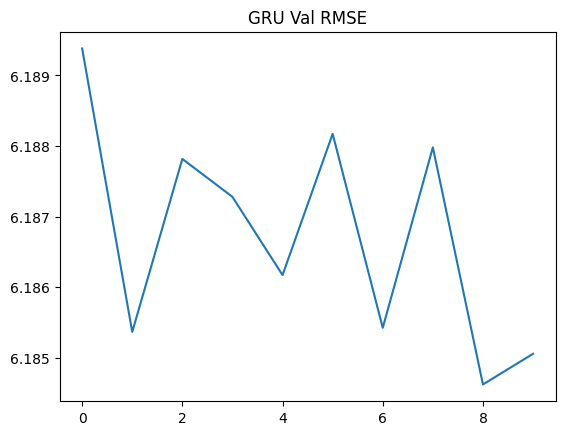

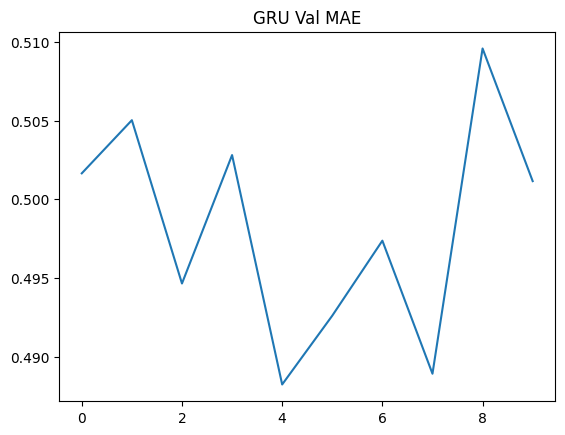

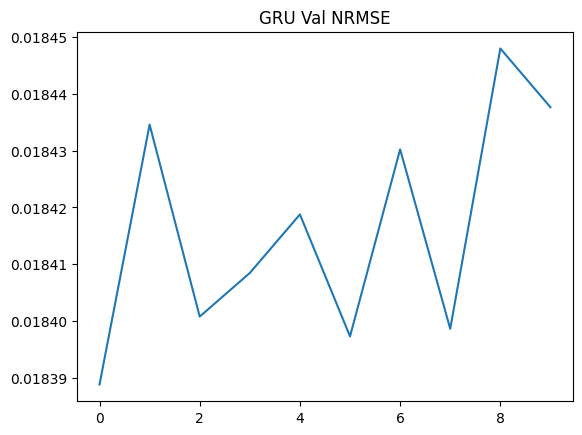

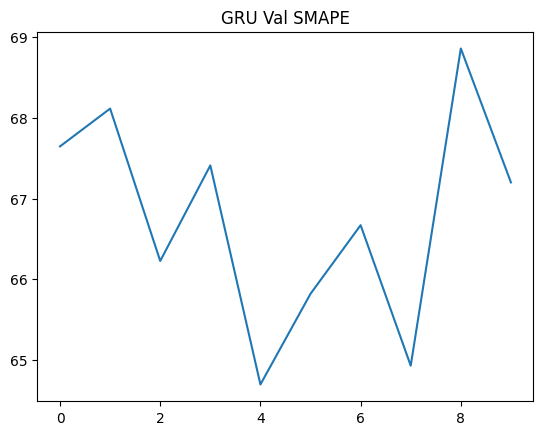

In [9]:
study_10min_sid = otimizar_GRU(X_train_10m[:,1:], 
                        y_train_10m, 
                        X_val_10m[:,1:], 
                        y_val_10m, 
                        "10minutos", 
                        inputs_10m, 
                        outputs_10m,
                        path_modelo='gru_10min_otimizada_sem_id.keras')

[I 2026-05-05 16:49:57,746] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 17:28:02,332] Trial 0 finished with value: 0.01847844384610653 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.46200231199272246, 'lstm_units': 51}. Best is trial 0 with value: 0.01847844384610653.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 17:45:40,465] Trial 1 finished with value: 0.01855270192027092 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.11672720296011092, 'lstm_units': 92}. Best is trial 0 with value: 0.01847844384610653.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 21:30:48,723] Trial 18 finished with value: 0.01847892627120018 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.49323653857420396, 'lstm_units': 112}. Best is trial 17 with value: 0.01843130774796009.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 21:38:41,173] Trial 19 finished with value: 0.018447410315275192 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.41062073006040756, 'lstm_units': 41}. Best is trial 17 with value: 0.01843130774796009.



Melhor NRMSE: 0.01843130774796009
Melhores parâmetros: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.49277577495097885, 'lstm_units': 44}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:6.283289432525635   val:6.185125827789307            
MAE:
    teste:0.5095750093460083   val:0.49825289845466614            
NRMSE:
  teste:0.022025927901268005   val:0.01844474859535694            
SMAPE:
  teste:65.03025817871094   val:66.78907775878906


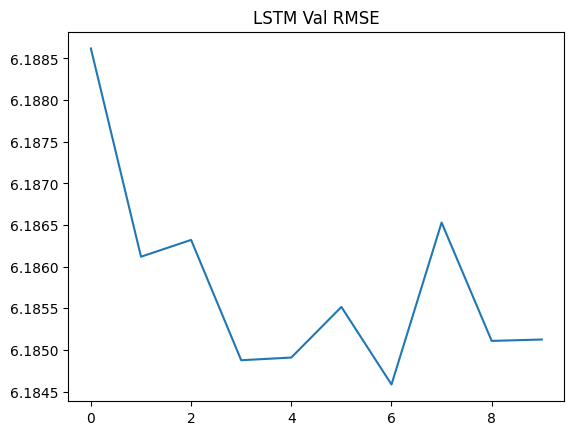

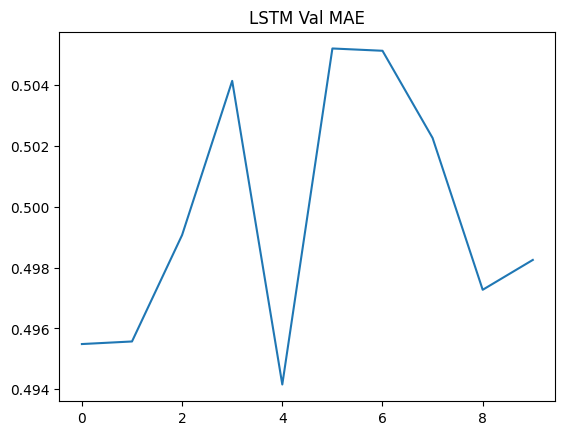

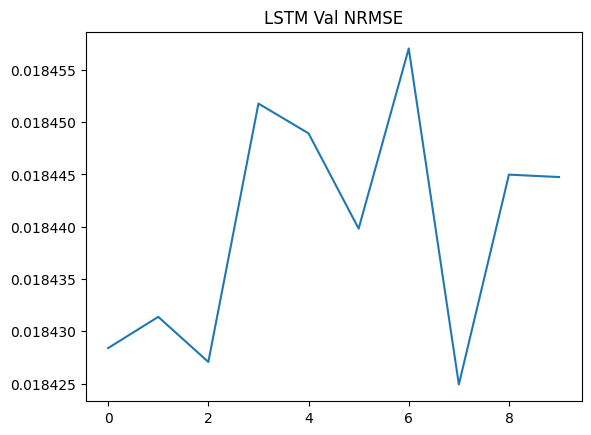

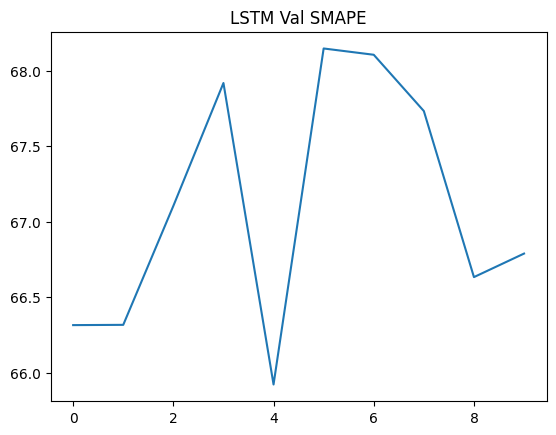

In [10]:
lstm_study_10min_sid = otimizar_LSTM(X_train_10m[:,1:], 
                        y_train_10m, 
                        X_val_10m[:,1:], 
                        y_val_10m, 
                        "10minutos", 
                        inputs_10m, 
                        outputs_10m,
                        path_modelo='lstm_10min_otimizada_sem_id.keras')

[I 2026-05-05 21:46:52,328] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 21:53:41,680] Trial 0 finished with value: 0.018502913415431976 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.3394079612902677, 'rnn_units': 111}. Best is trial 0 with value: 0.018502913415431976.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-05 22:21:37,118] Trial 1 finished with value: 0.018460143357515335 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.24988127042053782, 'rnn_units': 80}. Best is trial 1 with value: 0.018460143357515335.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 01:13:44,739] Trial 18 finished with value: 0.01848788373172283 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.38992064336581495, 'rnn_units': 112}. Best is trial 9 with value: 0.018409423530101776.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 01:29:44,689] Trial 19 finished with value: 0.018468128517270088 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4530478545273659, 'rnn_units': 50}. Best is trial 9 with value: 0.018409423530101776.



Melhor NRMSE: 0.018409423530101776
Melhores parâmetros: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.49070377241178276, 'rnn_units': 108}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:6.236955642700195   val:6.184896469116211                
MAE:
    teste:0.5110848546028137   val:0.5060092806816101                
NRMSE:
  teste:0.02186783216893673   val:0.018452055752277374                
SMAPE:
  teste:67.32080841064453   val:68.0218276977539


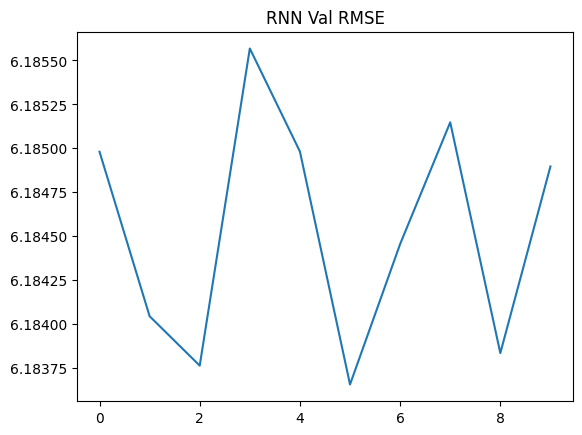

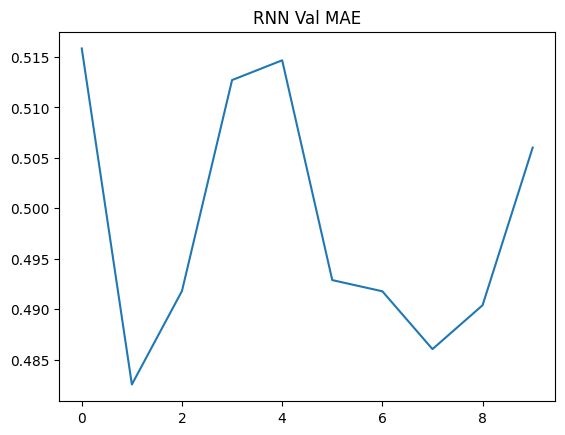

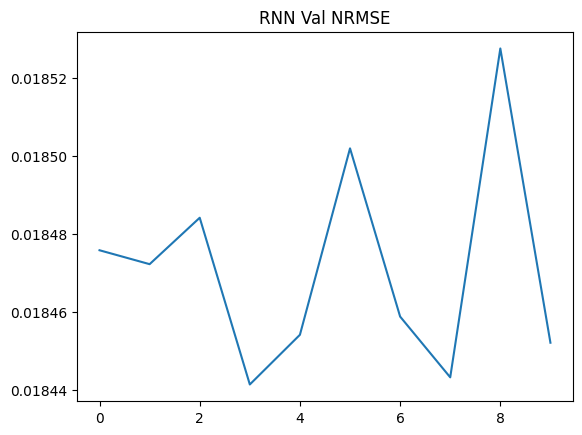

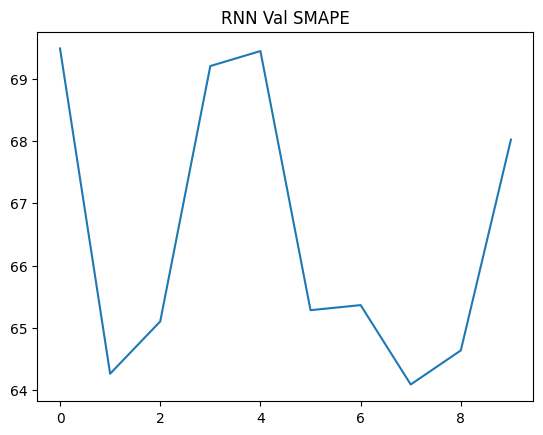

In [11]:
rnn_study_10min_sid = otimizar_RNN(X_train_10m[:,1:], 
                        y_train_10m, 
                        X_val_10m[:,1:], 
                        y_val_10m, 
                        "10minutos", 
                        inputs_10m, 
                        outputs_10m,
                        path_modelo='rnn_10min_otimizada_sem_id.keras')

[I 2026-05-06 01:36:43,215] A new study created in memory with name: Otimizacao_GRU


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 01:37:07,735] Trial 0 finished with value: 0.1679665595293045 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.1858885118498911, 'gru_units': 45}. Best is trial 0 with value: 0.1679665595293045.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 01:37:33,363] Trial 1 finished with value: 0.16674482822418213 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.11624633361428166, 'gru_units': 66}. Best is trial 1 with value: 0.16674482822418213.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 01:44:58,276] Trial 18 finished with value: 0.16527819633483887 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.3214207382355948, 'gru_units': 78}. Best is trial 15 with value: 0.16283564269542694.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 01:45:33,399] Trial 19 finished with value: 0.16232454776763916 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4404703002822633, 'gru_units': 33}. Best is trial 19 with value: 0.16232454776763916.



Melhor NRMSE: 0.16232454776763916
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4404703002822633, 'gru_units': 33}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.16522006690502167   val:0.17418131232261658            
MAE:
    teste:0.12541142106056213   val:0.1318885087966919            
NRMSE:
  teste:0.1609494686126709   val:0.1654764711856842            
SMAPE:
  teste:25.659629821777344   val:28.078779220581055


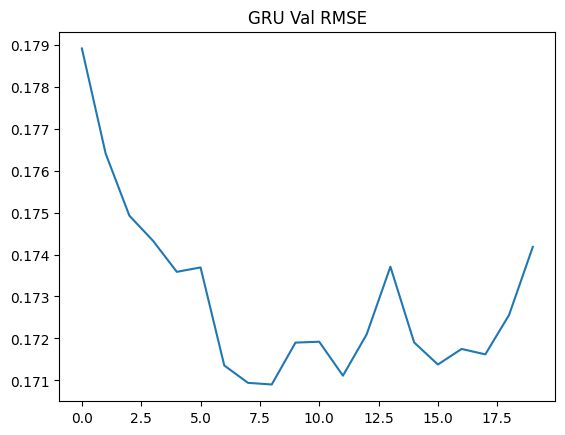

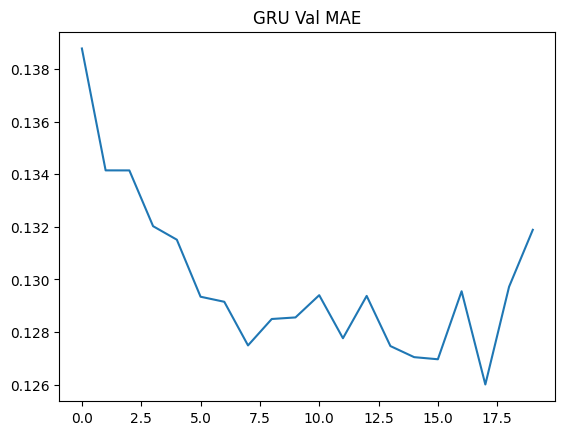

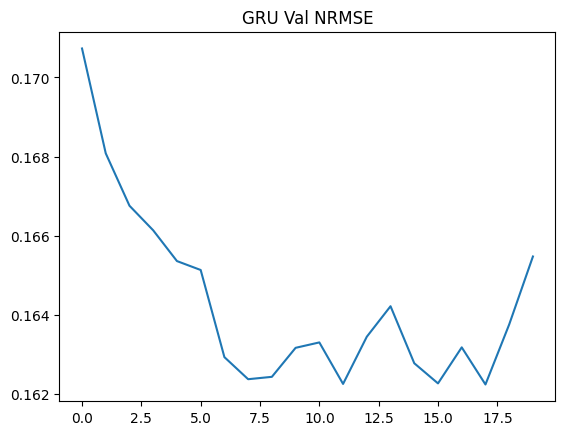

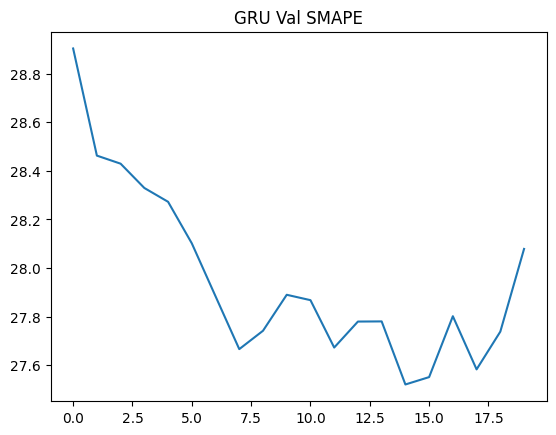

In [12]:
study_d_sid = otimizar_GRU(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='gru_diaria_otimizada_sem_id.keras')

[I 2026-05-06 01:46:04,441] A new study created in memory with name: Otimizacao_GRU


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 02:06:14,095] Trial 0 finished with value: 0.05630721151828766 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.2791770598385606, 'gru_units': 37}. Best is trial 0 with value: 0.05630721151828766.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 02:09:26,844] Trial 1 finished with value: 0.058239758014678955 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.33922005631264196, 'gru_units': 42}. Best is trial 0 with value: 0.05630721151828766.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 06:18:12,019] Trial 18 finished with value: 0.055715423077344894 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.386534576024094, 'gru_units': 112}. Best is trial 14 with value: 0.05529791861772537.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 06:31:27,078] Trial 19 finished with value: 0.055764153599739075 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.20117721634439006, 'gru_units': 50}. Best is trial 14 with value: 0.05529791861772537.



Melhor NRMSE: 0.05529791861772537
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.20355380141733137, 'gru_units': 102}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.07083337008953094   val:0.06844158470630646            
MAE:
    teste:0.042679641395807266   val:0.037325419485569            
NRMSE:
  teste:0.06977124512195587   val:0.05535569787025452            
SMAPE:
  teste:41.96488571166992   val:39.95479202270508


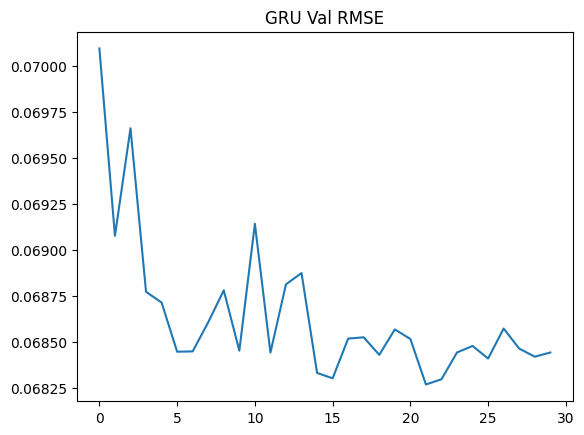

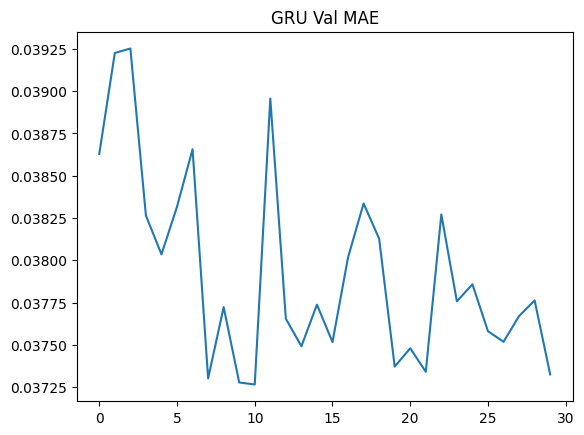

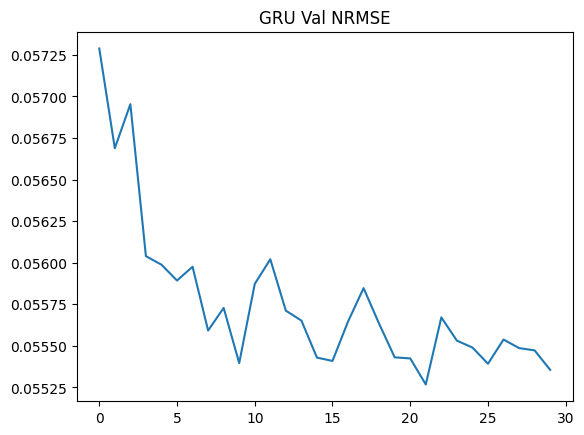

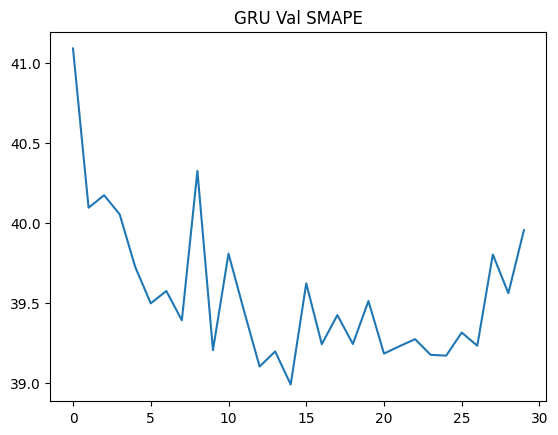

In [13]:
study_h_sid = otimizar_GRU(X_train_h[:,1:], 
                       y_train_h, 
                       X_val_h[:,1:], 
                       y_val_h, 
                       "horária", 
                       inputs_hour,
                       outputs_hour,
                       path_modelo= 'gru_horaria_otimizada_sem_id.keras')

[I 2026-05-06 06:53:25,454] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 06:53:32,984] Trial 0 finished with value: 0.17322571575641632 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.2131840361662357, 'rnn_units': 72}. Best is trial 0 with value: 0.17322571575641632.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 06:54:13,244] Trial 1 finished with value: 0.16765081882476807 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.26276554029440413, 'rnn_units': 128}. Best is trial 1 with value: 0.16765081882476807.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 07:01:38,219] Trial 18 finished with value: 0.1672949343919754 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.25510643662741006, 'rnn_units': 85}. Best is trial 12 with value: 0.16674897074699402.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 07:01:50,353] Trial 19 finished with value: 0.17440050840377808 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.17932205921535396, 'rnn_units': 102}. Best is trial 12 with value: 0.16674897074699402.



Melhor NRMSE: 0.16674897074699402
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.10940858195285474, 'rnn_units': 97}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.17353469133377075   val:0.17491643130779266                
MAE:
    teste:0.13286788761615753   val:0.1338244378566742                
NRMSE:
  teste:0.1698395013809204   val:0.16686521470546722                
SMAPE:
  teste:26.276371002197266   val:28.296175003051758


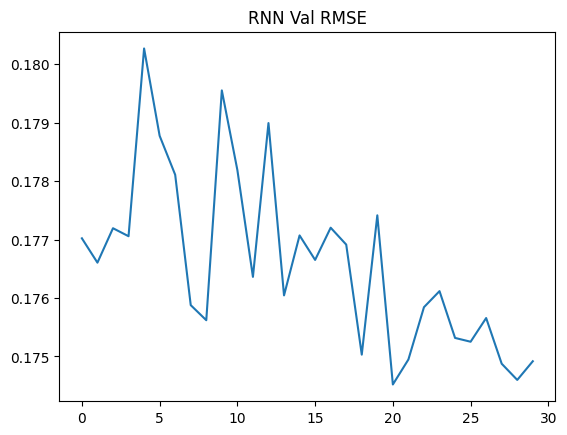

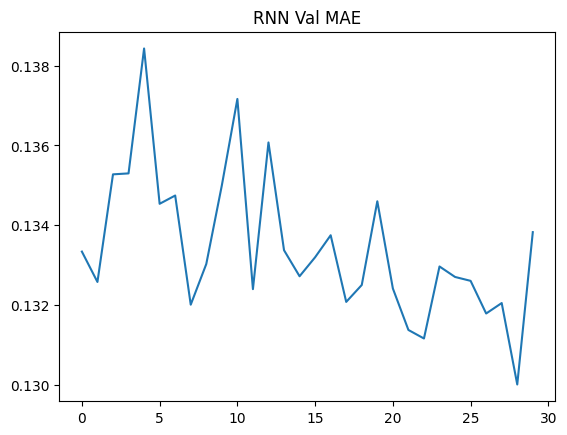

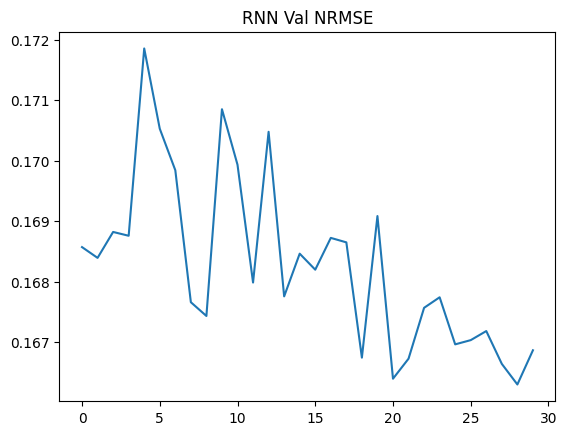

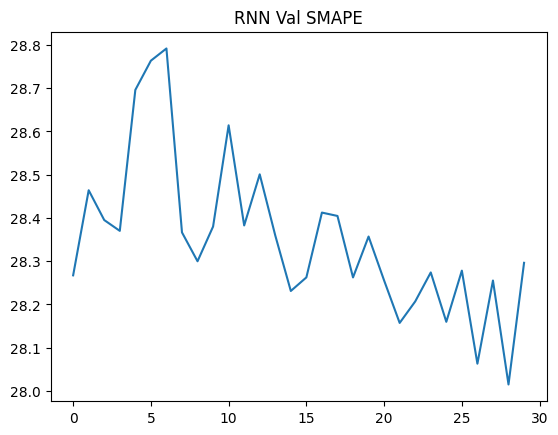

In [14]:
rnn_study_d_sid = otimizar_RNN(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='rnn_diaria_otimizada_sem_id.keras')

[I 2026-05-06 07:02:31,072] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 07:08:06,679] Trial 0 finished with value: 0.060564395040273666 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.11408886681832492, 'rnn_units': 86}. Best is trial 0 with value: 0.060564395040273666.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 07:14:18,685] Trial 1 finished with value: 0.0607842393219471 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.19101513665693204, 'rnn_units': 125}. Best is trial 0 with value: 0.060564395040273666.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 10:01:18,909] Trial 18 finished with value: 0.06008709594607353 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.26329677363339826, 'rnn_units': 94}. Best is trial 12 with value: 0.05976486951112747.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 10:12:20,830] Trial 19 finished with value: 0.061077363789081573 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4910378156162719, 'rnn_units': 128}. Best is trial 12 with value: 0.05976486951112747.



Melhor NRMSE: 0.05976486951112747
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.16660181080321035, 'rnn_units': 98}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.07676196843385696   val:0.07397369295358658                
MAE:
    teste:0.04790029674768448   val:0.04224243387579918                
NRMSE:
  teste:0.07576468586921692   val:0.061343975365161896                
SMAPE:
  teste:44.449073791503906   val:45.49654006958008


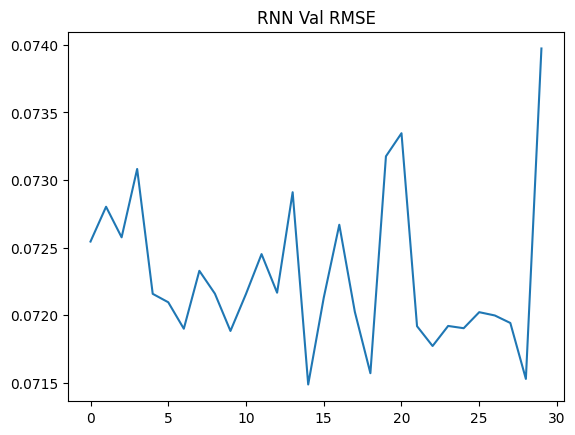

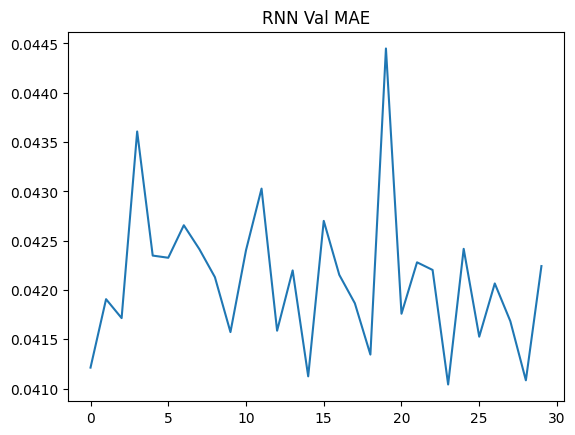

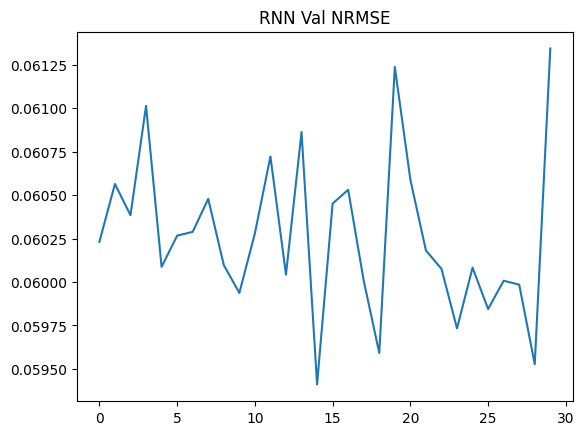

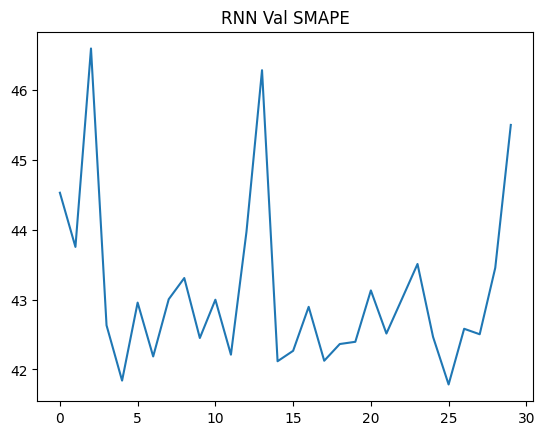

In [15]:
rnn_study_h_sem_id = otimizar_RNN(
                          X_train_h[:,1:], 
                          y_train_h, 
                          X_val_h[:,1:], 
                          y_val_h, 
                          "horária", 
                          inputs_hour,
                          outputs_hour,
                          path_modelo= ('rnn_horaria_otimizada_sem_id.keras')
)

[I 2026-05-06 10:28:56,054] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 10:29:27,199] Trial 0 finished with value: 0.1646614670753479 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.1398105784123015, 'lstm_units': 91}. Best is trial 0 with value: 0.1646614670753479.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 10:29:49,652] Trial 1 finished with value: 0.16650916635990143 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.3194176506903499, 'lstm_units': 113}. Best is trial 0 with value: 0.1646614670753479.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 10:35:19,782] Trial 18 finished with value: 0.16823098063468933 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.49066694187309323, 'lstm_units': 43}. Best is trial 11 with value: 0.16216497123241425.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 10:35:28,517] Trial 19 finished with value: 0.16487300395965576 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.4187834433463584, 'lstm_units': 60}. Best is trial 11 with value: 0.16216497123241425.



Melhor NRMSE: 0.16216497123241425
Melhores parâmetros: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.41626653725011875, 'lstm_units': 62}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.16479745507240295   val:0.1713102012872696            
MAE:
    teste:0.12462806701660156   val:0.12665437161922455            
NRMSE:
  teste:0.1606021374464035   val:0.16216349601745605            
SMAPE:
  teste:25.468381881713867   val:27.8627986907959


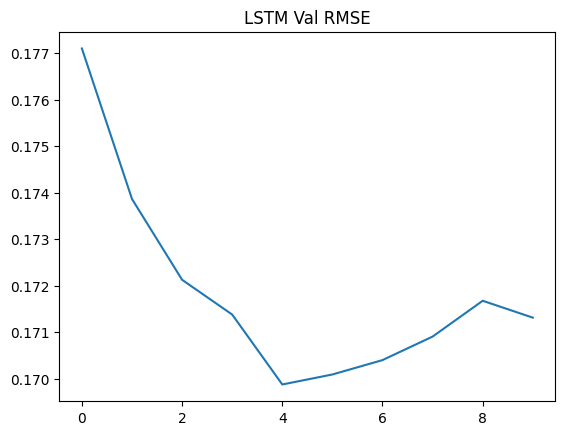

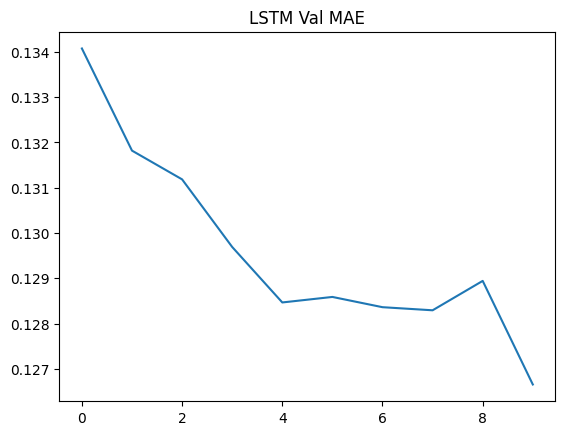

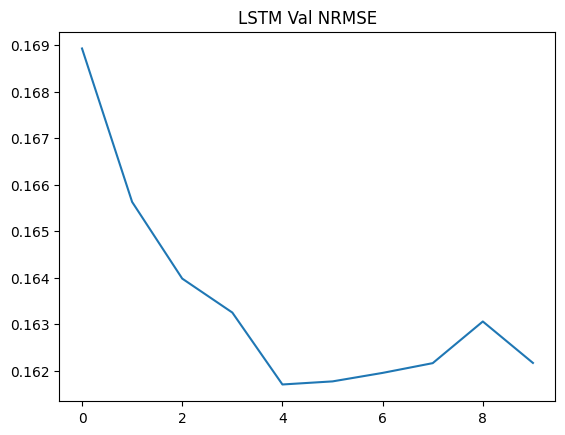

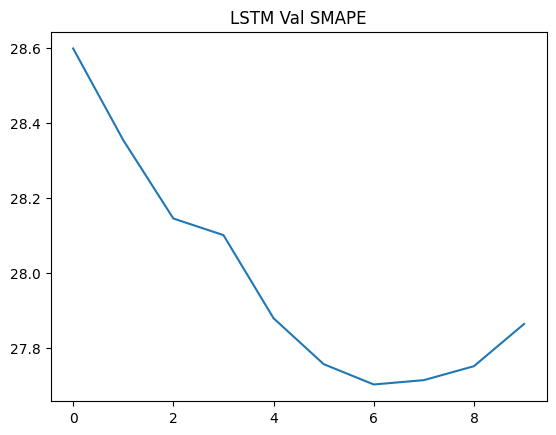

In [16]:
lstm_study_d_sid = otimizar_LSTM(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo='lstm_diaria_otimizada_sem_id.keras'
                        )

[I 2026-05-06 10:35:43,948] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 10:38:01,157] Trial 0 finished with value: 0.058540601283311844 and parameters: {'batch_size': 64, 'epochs': 10, 'dropout_rate': 0.1824279342118537, 'lstm_units': 86}. Best is trial 0 with value: 0.058540601283311844.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 10:42:57,521] Trial 1 finished with value: 0.0582272969186306 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.10474734227580487, 'lstm_units': 124}. Best is trial 1 with value: 0.0582272969186306.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 14:50:07,830] Trial 18 finished with value: 0.056406170129776 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.16022899255127387, 'lstm_units': 95}. Best is trial 17 with value: 0.05531526729464531.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-05-06 15:05:10,214] Trial 19 finished with value: 0.055914994329214096 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.3476717488519353, 'lstm_units': 93}. Best is trial 17 with value: 0.05531526729464531.



Melhor NRMSE: 0.05531526729464531
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.13915689992148592, 'lstm_units': 97}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.0701407641172409   val:0.06851527839899063            
MAE:
    teste:0.04181656241416931   val:0.037841010838747025            
NRMSE:
  teste:0.06908191740512848   val:0.055585265159606934            
SMAPE:
  teste:41.071388244628906   val:39.37458801269531


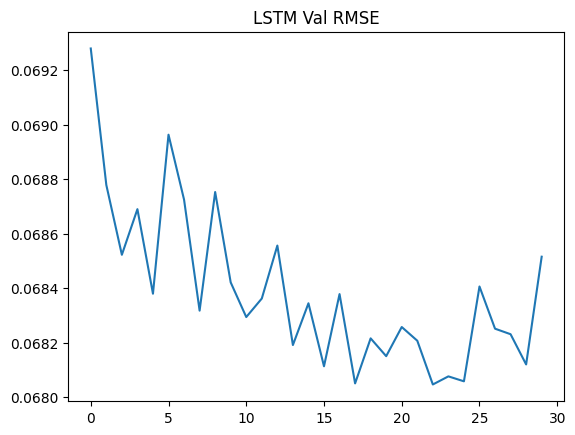

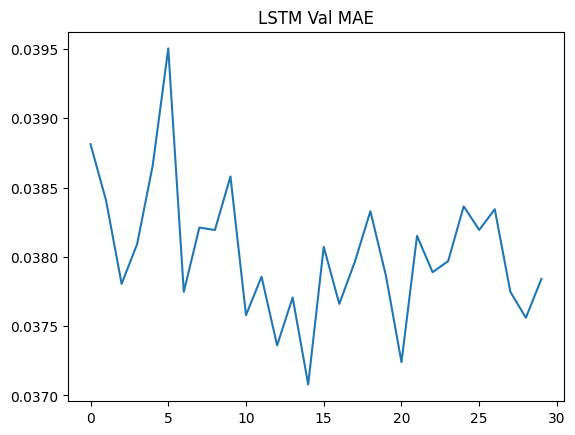

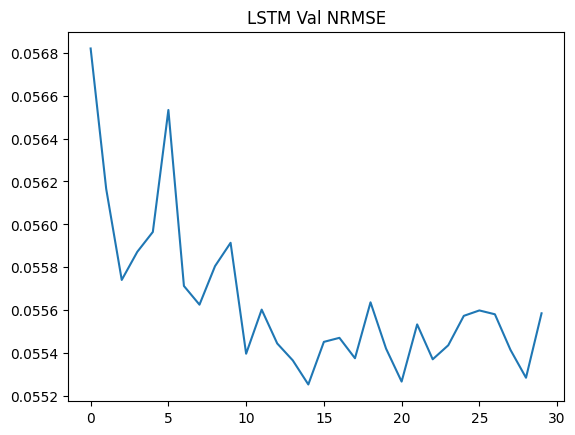

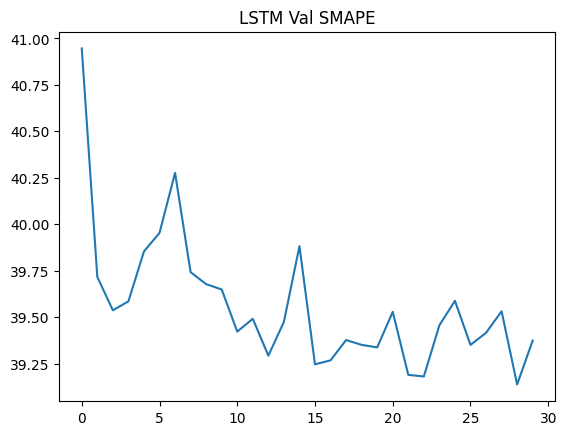

In [17]:
lstm_study_h_sid = otimizar_LSTM(
                          X_train_h[:,1:], 
                          y_train_h, 
                          X_val_h[:,1:],
                            y_val_h,
                            "horária",
                            inputs_hour,
                            outputs_hour,
                            path_modelo= 'lstm_horaria_otimizada_sem_id.keras'
)

In [20]:
from keras.models import load_model
dim_keys = ["Horario", "Diario", "10minutos"]
model_keys = ["GRU", "LSTM", "RNN"]

modelos ={
    "GRU":{
        "Diario": load_model('../../MODELOS/gru_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/gru_horaria_otimizada_sem_id.keras', compile=False),
        "10minutos": load_model('../../MODELOS/gru_10min_otimizada_sem_id.keras', compile=False)
    },
    "LSTM":{
        "Diario": load_model('../../MODELOS/lstm_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/lstm_horaria_otimizada_sem_id.keras', compile=False),
        "10minutos": load_model('../../MODELOS/lstm_10min_otimizada_sem_id.keras', compile=False)
    },
    "RNN":{
        "Diario": load_model('../../MODELOS/rnn_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/rnn_horaria_otimizada_sem_id.keras', compile=False),
        "10minutos": load_model('../../MODELOS/rnn_10min_otimizada_sem_id.keras', compile=False)
    }
}

In [17]:
new_train_d = modelos["GRU"]["Diario"].predict(X_train_d[:,1:].reshape(X_train_d.shape[0], 1, X_train_d.shape[1]-1))
new_train_h = modelos["GRU"]["Horario"].predict(X_train_h[:,1:].reshape(X_train_h.shape[0], 1, X_train_h.shape[1]-1))
new_train_c = np.hstack((new_train_d, new_train_h))

new_val_d = modelos["GRU"]["Diario"].predict(X_val_d[:,1:].reshape(X_val_d.shape[0], 1, X_val_d.shape[1]-1))
new_val_h = modelos["GRU"]["Horario"].predict(X_val_h[:,1:].reshape(X_val_h.shape[0], 1, X_val_h.shape[1]-1))
new_val_c = np.hstack((new_val_d, new_val_h))

new_test_d = modelos["GRU"]["Diario"].predict(X_test_d[:,1:].reshape(X_test_d.shape[0], 1, X_test_d.shape[1]-1))
new_test_h = modelos["GRU"]["Horario"].predict(X_test_h[:,1:].reshape(X_test_h.shape[0], 1, X_test_h.shape[1]-1))
new_test_c = np.hstack((new_test_d, new_test_h))

841/841 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step
841/841 ━━━━━━━━━━━━━━━━━━━━ 1s 636us/step
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step


[I 2026-03-18 16:30:45,548] A new study created in memory with name: Otimizacao_MLP


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-18 16:31:00,044] Trial 0 finished with value: 0.06383540481328964 and parameters: {'batch_size': 64, 'epochs': 10, 'dropout_rate': 0.40645742527514805, 'dense_units': 431, 'layers': 2}. Best is trial 0 with value: 0.06383540481328964.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-18 16:31:39,434] Trial 1 finished with value: 0.06367634236812592 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.32830497104386214, 'dense_units': 497, 'layers': 2}. Best is trial 1 with value: 0.06367634236812592.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-18 16:40:16,281] Trial 18 finished with value: 0.060870684683322906 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.10680750993649157, 'dense_units': 352, 'layers': 1}. Best is trial 17 with value: 0.05965189263224602.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-03-18 16:40:50,412] Trial 19 finished with value: 0.0603041909635067 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.34992673379784606, 'dense_units': 247, 'layers': 1}. Best is trial 17 with value: 0.05965189263224602.



Melhor NRMSE: 0.05965189263224602
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.14013317548407123, 'dense_units': 328, 'layers': 1}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.06649328023195267   val:0.0676184892654419            
MAE:
    teste:0.038074132055044174   val:0.03815077617764473            
NRMSE:
  teste:0.0653398185968399   val:0.06100514158606529            
SMAPE:
  teste:40.8159065246582   val:42.189002990722656


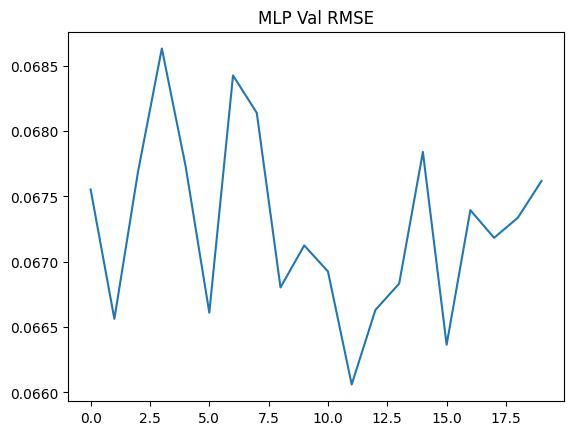

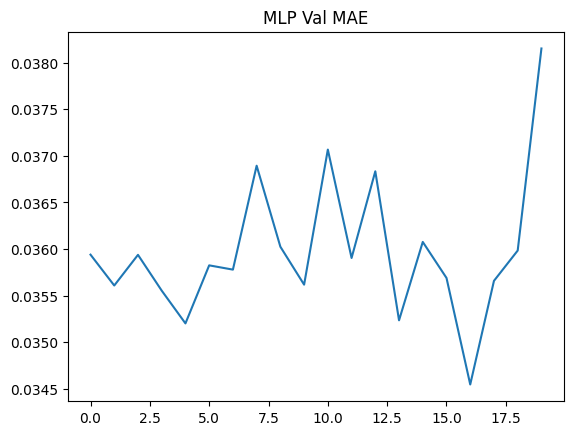

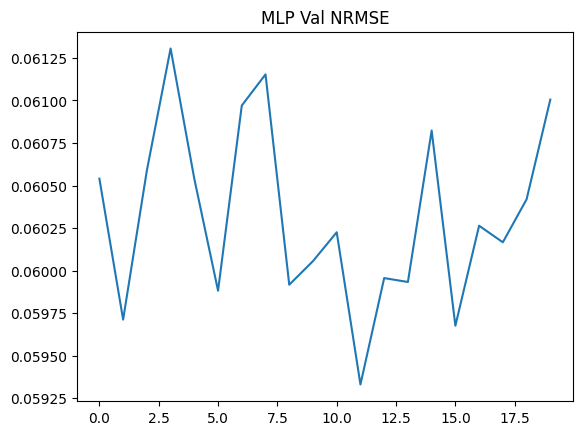

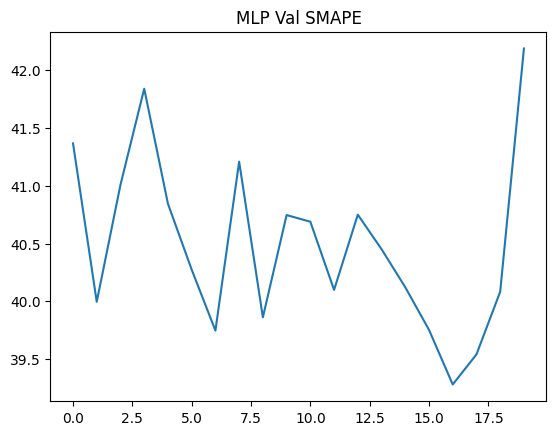

In [45]:
study_mlp_c = otimizar_MLP(new_train_c,
                            y_train_h,
                            new_val_c,
                            y_val_h,
                            "combinada",
                            new_train_c.shape[1],
                            outputs_hour,
                            path_modelo='mlp_combinada_otimizada.keras'
                            )

## Funções de avaliação modelos

In [18]:
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

def avaliar_modelo(y_real, y_previsto, verbose = False):
    mse = mean_squared_error(y_real, y_previsto)
    rmse = math.sqrt(mse)
    nrmse = rmse / (max(y_real) - min(y_real))
    mae = mean_absolute_error(y_real, y_previsto)
    _smape = smape(y_real, y_previsto) 
    if verbose:
        print(f"--- Desempenho: ---")
        print(f"RMSE (Erro Médio): {rmse:.4f}")
        print(f"MAE  (Erro Absoluto): {mae:.4f}")
        print(f"SMAPE: {_smape:.4f}")
        print(f"NRMSE: {nrmse:.4f}")
        print("-" * 30)
    return {"RMSE": rmse, "MAE": mae, "NRMSE": nrmse, "SMAPE": _smape}

def comparar_desempeho_granularidade(X_test_d, X_test_h, X_test_10m, y_test_d, y_test_h, y_test_10m, MODELO_d, MODELO_h,MODELO_10MIN):
    print("Carregando modelos...")
    y_pred_d = MODELO_d.predict(X_test_d)
    y_pred_h = MODELO_h.predict(X_test_h)
    y_pred_10m = MODELO_10MIN.predict(X_test_10m)
    
    print(f"Desempenho do modelo para granularidade diária:")
    resultado_d = avaliar_modelo(y_test_d.flatten(), y_pred_d.flatten(), verbose=True)
    
    print(f"Desempenho do modelo para granularidade horária:")
    resultado_h = avaliar_modelo(y_test_h.flatten(), y_pred_h.flatten(), verbose=True)

    print(f"Desempenho do modelo para granularidade 10minutos:")
    resultado_10m = avaliar_modelo(y_test_10m.flatten(), y_pred_10m.flatten(), verbose=True)    
    
    return {"Diario": resultado_d, "Horario": resultado_h, "10minutos:": resultado_10m}

def separar_dados_por_instituicao(inst, X_test, y_test =  None):
    idx = np.where(X_test[:,0] == inst)[0]
    X_test_i = X_test[idx]
    if y_test is not None:
        y_test_i = y_test[idx]
        return X_test_i, y_test_i
    else:
        return X_test_i
def avaliar_modelo_inst(inst:list,X_test_d, X_test_h, y_test_d, y_test_h, modelo_d, modelo_h):
    resultados = {
        "instituição": [],
        "granularidade:": [],
        "MAE": [],
        "RMSE": [],
        "NRMSE": [],
        "SMAPE": []
    }
    for i in inst:
        print(f"\n##############################\n \
Avaliando instituição {i}... \
                \n##############################\n")
        X_test_d_i, y_test_d_i = separar_dados_por_instituicao(i, X_test_d, y_test_d)
        X_test_h_i, y_test_h_i = separar_dados_por_instituicao(i, X_test_h, y_test_h)
        resultado = comparar_desempeho_granularidade(X_test_d_i, X_test_h_i, y_test_d_i, y_test_h_i, modelo_d, modelo_h)
        resultados["instituição"].append(i)
        resultados["granularidade:"].append("diária")
        resultados["MAE"].append(resultado["Diario"]["MAE"])
        resultados["RMSE"].append(resultado["Diario"]["RMSE"])
        resultados["NRMSE"].append(resultado["Diario"]["NRMSE"])
        resultados["SMAPE"].append(resultado["Diario"]["SMAPE"])

        resultados["instituição"].append(i)
        resultados["granularidade:"].append("horária")
        resultados["MAE"].append(resultado["Horario"]["MAE"])
        resultados["RMSE"].append(resultado["Horario"]["RMSE"])
        resultados["NRMSE"].append(resultado["Horario"]["NRMSE"])
        resultados["SMAPE"].append(resultado["Horario"]["SMAPE"])
    return pd.DataFrame(resultados)



        
        



## Avaliação de modelos

In [21]:

metricas = {}
for model in model_keys:
    print(model)
    metricas[model] = comparar_desempeho_granularidade(
        X_test_d[:,1:].reshape((X_test_d.shape[0], 1, X_test_d.shape[1]-1)), 
        X_test_h[:,1:].reshape((X_test_h.shape[0], 1, X_test_h.shape[1]-1)),
        X_test_10m[:,1:].reshape((X_test_10m.shape[0], 1, X_test_10m.shape[1]-1)), 
        y_test_d[:,0], 
        y_test_h[:,:24],
        y_test_10m[:,:24*6],
        modelos[model]["Diario"],
        modelos[model]["Horario"],
        modelos[model]["10minutos"]
    )

GRU
Carregando modelos...
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step
9091/9091 ━━━━━━━━━━━━━━━━━━━━ 5s 568us/step
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1417
MAE  (Erro Absoluto): 0.1147
SMAPE: 40.5173
NRMSE: 0.0900
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.0566
MAE  (Erro Absoluto): 0.0293
SMAPE: 43.8918
NRMSE: 0.0272
------------------------------
Desempenho do modelo para granularidade 10minutos:
--- Desempenho: ---
RMSE (Erro Médio): 6.2838
MAE  (Erro Absoluto): 0.4981
SMAPE: 69.7209
NRMSE: 0.0221
------------------------------
LSTM
Carregando modelos...
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 1s 417us/step
9091/9091 ━━━━━━━━━━━━━━━━━━━━ 8s 844us/step
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1308
MAE  (Erro Absoluto): 0.0980
SMAPE: 37.464

In [49]:
mlp  = load_model('../../MODELOS/mlp_combinada_otimizada.keras', compile=False)
y_pred_c   = mlp.predict(new_test_c)
y_true_c   = y_test_h
avaliar_modelo(y_true_c[:,1:].flatten(), y_pred_c.flatten(), "MLP Combinada")

110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step
--- Desempenho: ---
RMSE (Erro Médio): 29.9787
MAE  (Erro Absoluto): 5.3405
SMAPE: 49.6589
NRMSE: 0.1055
------------------------------


{'RMSE': 29.978660623407404,
 'MAE': 5.340528964996338,
 'NRMSE': np.float32(0.10554526),
 'SMAPE': <tf.Tensor: shape=(), dtype=float32, numpy=49.65892028808594>}

In [22]:
predicoes = {}
predicoes_sem_escaler = {}
real = {
    "Diario": y_test_d[:,0],
    "Horario": y_test_h[:,:24]
}
for model in model_keys:
    print(model)
    predicoes[model] = {
        "Diario": modelos[model]["Diario"].predict(X_test_d[:,1:].reshape((X_test_d.shape[0], 1, X_test_d.shape[1]-1))),
        "Horario": modelos[model]["Horario"].predict(X_test_h[:,1:].reshape((X_test_h.shape[0], 1, X_test_h.shape[1]-1)))
    }
        

GRU
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 1s 489us/step
LSTM
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step
RNN
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 1s 372us/step


In [80]:
scalers_day.keys()

dict_keys(['189', '68', '217', '198', '150', '130', '64', '3', '41', '117', '238', '152', '151', '125', '74', '96', '239', '248', '10', '70', '119', '94', '4', '203', '115', '169', '72', '249', '213', '50', '192', '54', '223', '168', '178', '83', '66', '164', '265', '69', '55', '42', '39', '65', '172', '62', '12', '114', '173', '218', '165', '6', '9', '132', '38', '8', '53', '102', '105', '0', '143', '222', '200', '175', '133', '235', '193', '147', '5', '284', '45', '52', '67', '75', '25', '126', '31', '59', '180', '71', '232', '46', '205', '144', '215', '112', '244', '177', '108', '16', '40', '73', '27', '109', '63', '100', '106', '28', '155', '208', '183', '32', '252', '228', '30', '185', '179', '86', '216', '209', '35', '246', '34', '138', '84', '101', '23', '214', '136', '48', '79', '167', '82', '145', '22', '190', '107', '221', '60', '88', '206', '171', '199', '230', '113', '157', '191', '220', '98', '224', '57', '123', '111', '24', '196', '120', '95', '254', '141', '80', '156', '

In [27]:
scalers_day = joblib.load("/home/ismael/Documentos/GRANULARITY-PREDICTION/src/scalers/scalers_day.joblib")
scalers_hour = joblib.load("/home/ismael/Documentos/GRANULARITY-PREDICTION/src/scalers/scalers_hour.joblib")
scalers_10min = joblib.load("/home/ismael/Documentos/GRANULARITY-PREDICTION/src/scalers/scalers_10min.joblib")

In [28]:

real_sem_escaler = {}
predicoes_sem_escaler = {}
for model in model_keys:
    predicoes_sem_escaler[model] = {}
    predicoes_sem_escaler[model]["Diario"] = []
    real_sem_escaler["Diario"] = []
    df_d = pd.DataFrame({
            "previsto": predicoes[model]["Diario"].flatten()
        })
    df_d_real = pd.DataFrame({
            "real": real["Diario"].flatten()
        })
    for i in inst:
        df_d["i"] = X_test_d[:,0]
        df_d_real["i"] = X_test_d[:,0]
        
        df_d_i = df_d[df_d["i"] == int(i)]
        sem_scaler = scalers_day[i].inverse_transform(df_d_i["previsto"].values.reshape(-1, 1))
        sem_scaler_real = scalers_day[i].inverse_transform(df_d_real[df_d_real["i"] == int(i)]["real"].values.reshape(-1, 1))
        predicoes_sem_escaler[model]["Diario"].extend(sem_scaler.flatten()) 
        real_sem_escaler["Diario"].extend(sem_scaler_real.flatten())

    predicoes_sem_escaler[model]["Diario"] = np.array(predicoes_sem_escaler[model]["Diario"])
    real_sem_escaler["Diario"] = np.array(real_sem_escaler["Diario"])
        

In [29]:
import numpy as np

ids_instituicoes = X_test_h[:, 0]
instituicoes_unicas = np.unique(ids_instituicoes)

for model in model_keys:
    preds_originais = predicoes[model]["Horario"]
    real_originais = real["Horario"]
    
    # Listas temporárias para guardar os dados limpos e as posições originais deles
    linhas_revertidas = []
    indices_originais = []
    linhas_revertidas_real = []
    indices_originais_real = []

    for i in instituicoes_unicas:
        # Pega as posições exatas (números das linhas) onde esta instituição aparece na matriz original
        indices_inst = np.where(ids_instituicoes == i)[0]

        # Aplica o salto de 24 em 24 apenas nesses índices
        indices_filtrados = indices_inst

        if len(indices_filtrados) > 0:
            scaler = scalers_hour[str(int(i))]
            
            # Puxa os dados da matriz original usando os índices já filtrados
            dados_inst_filtrado = preds_originais[indices_filtrados]
            real_inst_filtrado = real_originais[indices_filtrados]

            # Achata, desnormaliza e devolve para o formato de colunas
            dados_achatados = dados_inst_filtrado.reshape(-1, 1)
            dados_revertidos = scaler.inverse_transform(dados_achatados).reshape(dados_inst_filtrado.shape)
            real_achatados = real_inst_filtrado.reshape(-1, 1)
            real_revertidos = scaler.inverse_transform(real_achatados).reshape(real_inst_filtrado.shape)

            # Guarda os dados revertidos e anota a posição original de cada um
            linhas_revertidas.extend(dados_revertidos)
            indices_originais.extend(indices_filtrados)
            linhas_revertidas_real.extend(real_revertidos)
            indices_originais_real.extend(indices_filtrados)

    # Converte as listas de volta para matrizes do NumPy
    linhas_revertidas = np.array(linhas_revertidas)
    indices_originais = np.array(indices_originais)
    linhas_revertidas_real = np.array(linhas_revertidas_real)
    indices_originais_real = np.array(indices_originais_real)

    # O PASSO FUNDAMENTAL: Descobre a ordem correta para reembaralhar os dados de volta ao formato cronológico
    ordem_correta = np.argsort(indices_originais)
    
    # Salva a matriz perfeita, desnormalizada, filtrada e ordenada
    predicoes_sem_escaler[model]["Horario"] = linhas_revertidas[ordem_correta]
    real_sem_escaler["Horario"] = linhas_revertidas_real[np.argsort(indices_originais_real)]

In [72]:
horas_agregadas = {}
for model in model_keys:
    pred_cortada = predicoes_sem_escaler[model]["Horário"]
    horas_agregadas[model] = []
    for i in range(pred_cortada.shape[0]):
        soma_24h = np.sum(pred_cortada[i])
        horas_agregadas[model].append(soma_24h)
    horas_agregadas[model] = np.array(horas_agregadas[model])

In [73]:
diferencas = {}
media = {}
for model in model_keys:
    diferencas[model] = predicoes_sem_escaler[model]["Diário"].reshape(-1, 1) - horas_agregadas[model].reshape(-1, 1)
    diferencas[model] = diferencas[model]/horas_agregadas[model].reshape(-1, 1)

    media[model] = np.mean(np.abs(diferencas[model]))

ValueError: operands could not be broadcast together with shapes (3507,1) (80327,1) 

In [178]:
media

{'GRU': np.float32(0.20616467),
 'LSTM': np.float32(0.22872975),
 'RNN': np.float32(0.66478485)}

In [ ]:
df1 = pd.read_csv("../../RESULTADOS/avaliacao_por_instituicao.csv")
df1 = df1[df1["granularidade:"] == "horária"]



instituição              4
granularidade:      diária
MAE               0.135206
RMSE              0.151348
NRMSE             0.482698
SMAPE             62.30706
Name: 44, dtype: object

In [210]:
df1[df1["NRMSE"] >= 0.17]

,instituição,granularidade:,MAE,RMSE,NRMSE,SMAPE
0,189,diária,0.119681,0.135679,0.241493,71.733047
2,68,diária,0.084707,0.102925,0.423729,26.006598
4,217,diária,0.204103,0.273591,0.217273,44.121128
6,198,diária,0.089184,0.096957,0.448078,52.868717
8,150,diária,0.185408,0.233569,0.204779,30.180014
...,...,...,...,...,...,...
324,137,diária,0.121592,0.151585,0.277730,28.275181
326,93,diária,0.128342,0.139208,0.241355,72.145393
328,76,diária,0.117219,0.126987,0.284781,52.683685
330,118,diária,0.114414,0.136448,0.228537,12.199168


In [205]:
df1["NRMSE"].median()

np.float64(0.18851903825998306)

In [198]:
df1[["instituição","NRMSE"]].sort_values(by = "NRMSE").head(10)

,instituição,NRMSE
118,0,0.171340
300,156,0.171540
142,52,0.172691
72,66,0.179204
186,109,0.181062
206,228,0.187469
224,34,0.188246
190,100,0.188792
284,111,0.191308
322,201,0.194941


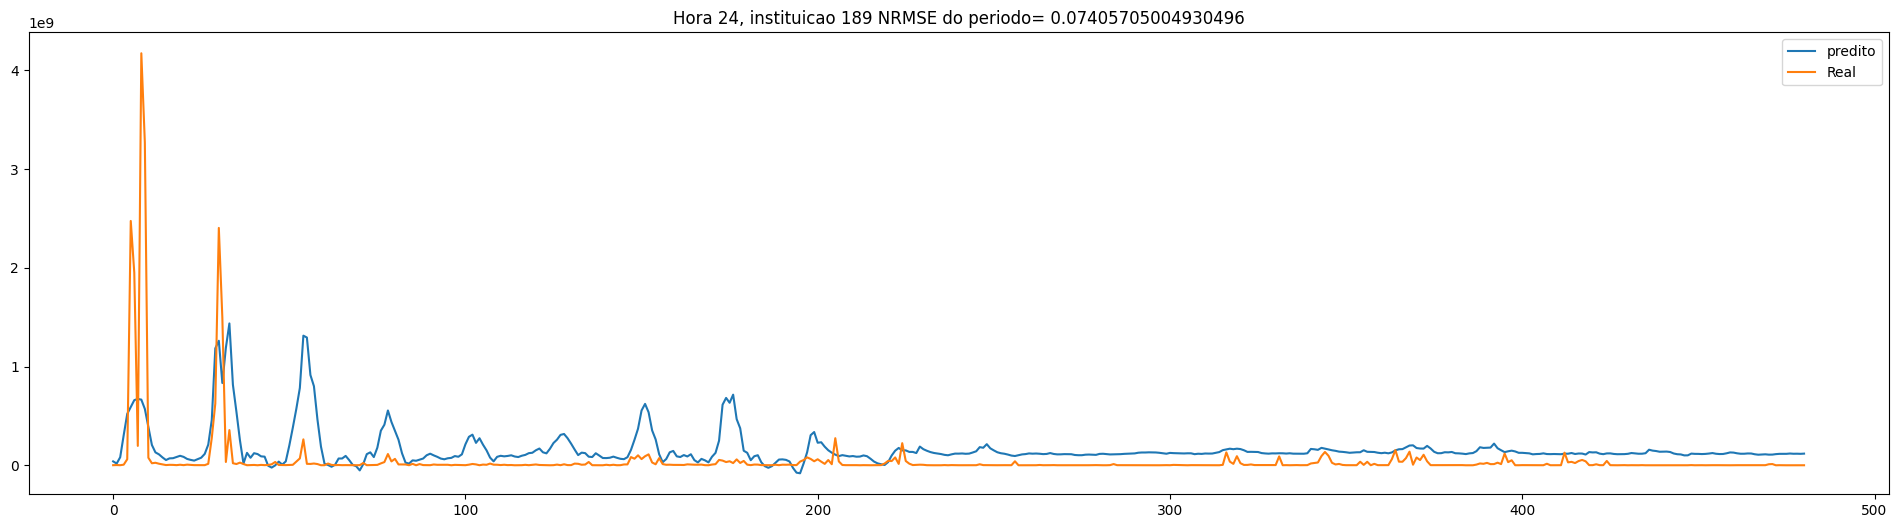

In [222]:
df1 = pd.read_csv("../../RESULTADOS/avaliacao_por_instituicao.csv")
t = 23
i = 189
import matplotlib.pyplot as plt
ids_instituicoes = X_test_h[:, 0]
indices_inst = np.where(ids_instituicoes == i)[0]
predicao = predicoes_sem_escaler["GRU"]["Horario"][indices_inst]
predicao = predicao[:,t]
real = real_sem_escaler["Horario"][indices_inst]
real = real[:,t]
plt.figure(figsize=(24, 6))
nmrse = avaliar_modelo(real.flatten(), predicao.flatten())["NRMSE"]
plt.title(f"Hora {t+1}, instituicao {str(i)} NRMSE do periodo= {nmrse}")
plt.plot(predicao.flatten(), label = "predito")

plt.plot(real.flatten(), label = "Real")
plt.legend()
plt.show()

In [193]:
real

array([4.3192284e+09, 3.8898122e+09, 1.6835369e+10, 6.6694221e+09,
       3.6381742e+09, 1.8306926e+09, 6.9564045e+08, 1.5267378e+09,
       1.4465307e+09, 2.0556225e+09, 2.2045942e+09, 2.7612383e+09,
       8.9181792e+08, 1.2549284e+09, 1.8392658e+09, 3.3290652e+09,
       5.2988390e+09, 3.0740408e+09, 1.8041878e+09, 1.3873091e+08,
       2.5971990e+08], dtype=float32)

In [189]:
X_test_d

array([[ 1.8900000e+02,  3.8173586e-01,  2.5488126e-01, ...,
         1.3717628e-01,  5.6502870e-03,  2.9177396e-03],
       [ 1.8900000e+02,  2.5488126e-01,  2.3600583e-01, ...,
         5.6502870e-03,  2.9177396e-03,  1.0927751e-01],
       [ 1.8900000e+02,  2.3600583e-01,  1.8432933e-01, ...,
         2.9177396e-03,  1.0927751e-01,  5.6185436e-01],
       ...,
       [ 1.0400000e+02,  7.0469819e-02,  1.1294924e-02, ...,
         4.9677512e-01,  5.6500757e-01,  3.9461222e-01],
       [ 1.0400000e+02,  1.1294924e-02, -1.5250631e-02, ...,
         5.6500757e-01,  3.9461222e-01,  2.9179445e-01],
       [ 1.0400000e+02, -1.5250631e-02,  4.9600199e-01, ...,
         3.9461222e-01,  2.9179445e-01,  3.9011143e-02]],
      shape=(3507, 8), dtype=float32)

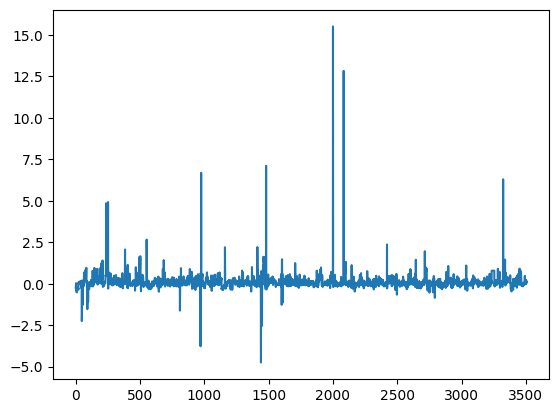

In [177]:
plt.plot(diferencas["GRU"].flatten())

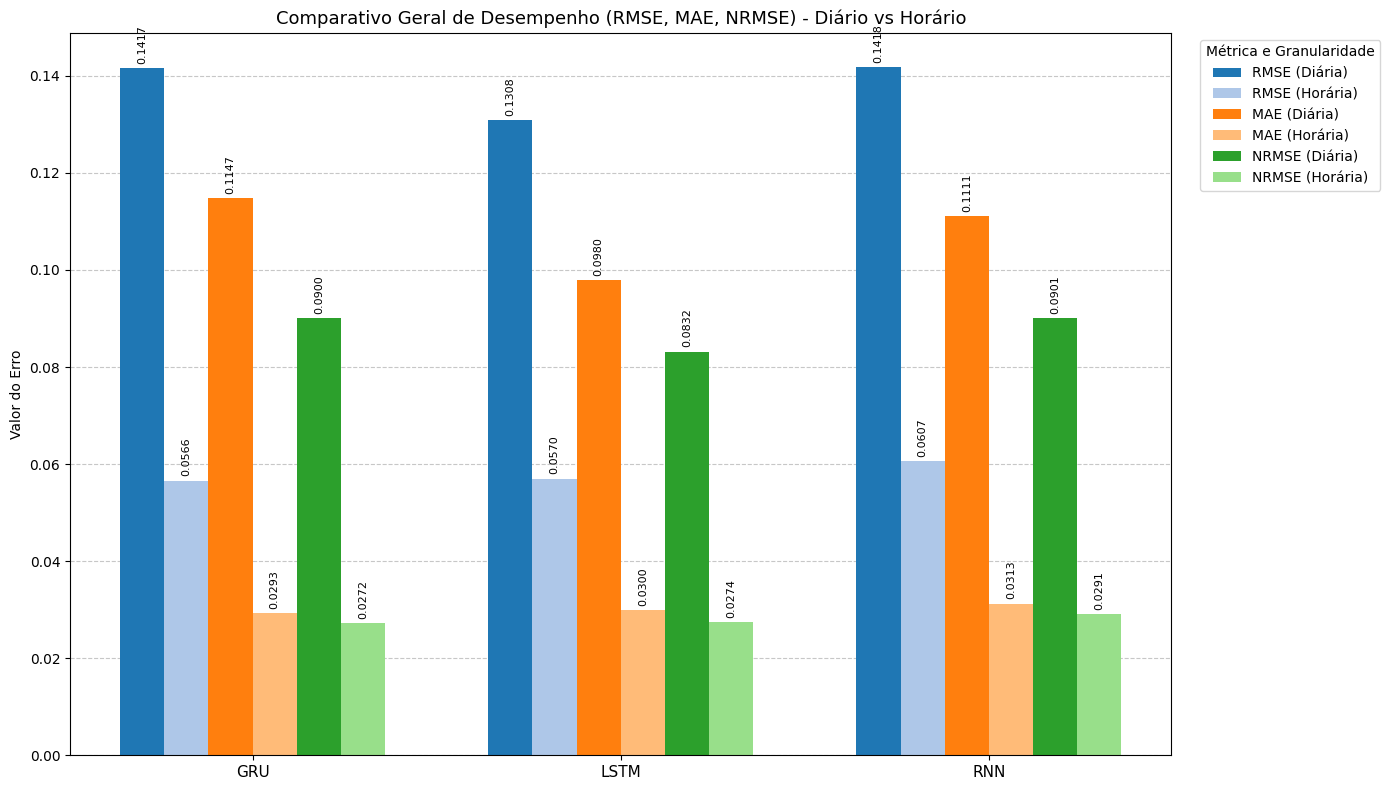

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# A sua estrutura de dicionário (Adicionei o GRU (SEM_ID) com valores aproximados baseados na imagem para ficar completo)


modelos = list(metricas.keys())
metricas_plot = ['RMSE', 'MAE', 'NRMSE'] # sMAPE fica de fora para não quebrar a escala visual

# Cores exatas extraídas da sua imagem de referência
cores = {
    'RMSE': {'Diario': '#1f77b4', 'Horario': '#aec7e8'},   # Azul escuro e claro
    'MAE':  {'Diario': '#ff7f0e', 'Horario': '#ffbb78'},   # Laranja escuro e claro
    'NRMSE': {'Diario': '#2ca02c', 'Horario': '#98df8a'}   # Verde escuro e claro
}

# Configuração do espaçamento das 6 barras
x = np.arange(len(modelos))
largura_barra = 0.12  
offsets = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5] # Multiplicadores para empurrar as barras lateralmente

fig, ax = plt.subplots(figsize=(14, 8)) # Largura maior para caber a legenda fora do quadro

# Loop inteligente para desenhar as 6 barras na ordem correta para cada modelo
idx_offset = 0
for metrica in metricas_plot:
    for granularidade in ['Diario', 'Horario']:
        valores = [metricas[modelo][granularidade][metrica] for modelo in modelos]
        posicao = x + (offsets[idx_offset] * largura_barra)
        
        # Ajuste gramatical para a legenda (Diario -> Diária)
        label = f'{metrica} ({"Diária" if granularidade == "Diario" else "Horária"})'
        cor = cores[metrica][granularidade]
        # 1. Capturamos as barras criadas na variável 'barras'
        barras = ax.bar(posicao, valores, largura_barra, label=label, color=cor)
        
        # 2. Adicionamos os valores no topo com rotação para não sobrepor
        ax.bar_label(barras, padding=3, fmt='%.4f', fontsize=8, rotation=90)
        idx_offset += 1

# Estilização idêntica à imagem
ax.set_ylabel('Valor do Erro')
ax.set_title('Comparativo Geral de Desempenho (RMSE, MAE, NRMSE) - Diário vs Horário', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)

# Configurando o Grid pontilhado atrás das barras
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) 

# Movendo a legenda para fora do gráfico (canto superior direito)
ax.legend(title='Métrica e Granularidade', bbox_to_anchor=(1.02, 1), loc='upper left')

# O tight_layout impede que a legenda seja cortada na hora de salvar
plt.tight_layout()
plt.show()

In [36]:
horas_agregadas["GRU"]

array([0.511021  , 0.49924216, 0.5099691 , ..., 0.5101657 , 0.51504576,
       0.60057425], shape=(80291,), dtype=float32)

In [37]:
y_test_h_df = pd.DataFrame(y_test_h, columns=[f"t+{i}" for i in range(1, y_test_h.shape[1]+1)])
inst = y_test_h_df.iloc[:, -1].values
for i in range(y_pred_h.shape[1]):
    y_test_h_df[f"pred+{i+1}"] = y_pred_h[:, i]
import numpy as np
import pandas as pd

# Quantidade real de passos temporais (excluindo a última coluna que é o ID)
num_passos = y_test_h.shape[1] - 1
coluna_id = f"t+{y_test_h.shape[1]}"

# Nomes das colunas em lote
colunas_pred = [f"pred+{i+1}" for i in range(num_passos)]
colunas_test = [f"t+{i+1}" for i in range(num_passos)]

ids_unicos = np.unique(y_test_h_df[coluna_id].values)

y_pred_h_resized = []
y_test_h_resized = []

for inst_id in ids_unicos:
    # Isola a instituição
    subset = y_test_h_df[y_test_h_df[coluna_id] == inst_id]
    scaler = scalers_hour[str(int(inst_id))]
    
    # 1. Extrai TODAS as colunas ao mesmo tempo e empilha em uma única coluna vertical (-1, 1)
    pred_empilhado = subset[colunas_pred].values.reshape(-1, 1)
    test_empilhado = subset[colunas_test].values.reshape(-1, 1)
    
    # 2. Reverte a escala da matriz inteira de uma vez e achata (.flatten()) para vetor 1D
    pred_invertido = scaler.inverse_transform(pred_empilhado).flatten()
    test_invertido = scaler.inverse_transform(test_empilhado).flatten()
    
    # 3. Adiciona à lista mestre
    y_pred_h_resized.extend(pred_invertido)
    y_test_h_resized.extend(test_invertido)

# 4. Converte o resultado final para arrays limpos do NumPy
y_pred_h_final = np.array(y_pred_h_resized)
y_test_h_final = np.array(y_test_h_resized)

NameError: name 'y_pred_h' is not defined

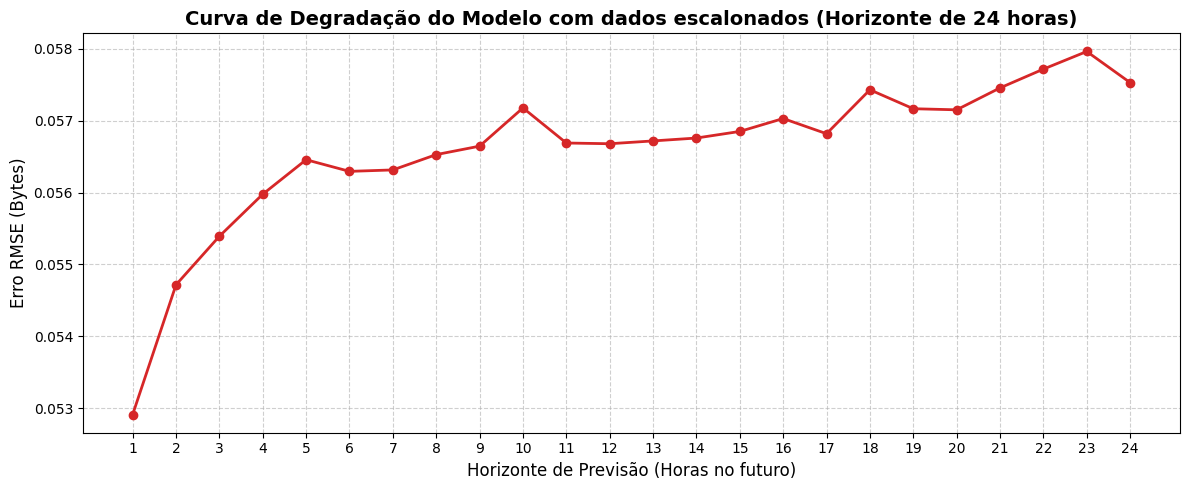

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Supondo que você tenha suas duas matrizes alinhadas:
# y_real_24h -> Matriz (N, 24) com os dados reais
# y_pred_24h -> Matriz (N, 24) com as previsões (ex: predicoes_sem_escaler["GRU"]["Horário"])

passos_futuros = 24
erros_por_horizonte = []

# 1. Calcula o erro separadamente para cada hora no futuro
for t in range(passos_futuros):
    # Pega apenas a coluna 't' de todas as linhas
    real_coluna = real["Horario"][:, t]
    pred_coluna = predicoes["GRU"]["Horario"][:, t]

    # Calcula o RMSE dessa hora específica
    rmse_atual = np.sqrt(mean_squared_error(real_coluna, pred_coluna))
    erros_por_horizonte.append(rmse_atual)

# 2. Plota a Curva de Degradação
plt.figure(figsize=(12, 5))
plt.plot(range(1, passos_futuros + 1), erros_por_horizonte, marker='o', color='#d62728', linewidth=2)

# Estilização
plt.title('Curva de Degradação do Modelo com dados escalonados (Horizonte de 24 horas)', fontsize=14, fontweight='bold')
plt.xlabel('Horizonte de Previsão (Horas no futuro)', fontsize=12)
plt.ylabel('Erro RMSE (Bytes)', fontsize=12)

# Garante que o eixo X mostre de 1 a 24 certinho
plt.xticks(range(1, passos_futuros + 1))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()